# German Credit Analysis

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn

from sklearn.preprocessing import LabelEncoder

from models.mlp import BlackBoxModel

pd.set_option('display.max_columns', None)

%reload_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.abspath("."))

In [2]:
def set_seed(seed=42):
    import os, random, numpy as np, torch
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)          
    np.random.seed(seed)       
    torch.manual_seed(seed)    
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
seed=42

# Read and Process Data

In [3]:
df_ = pd.read_csv('data/german_credit/german_credit_data.csv')
df = df_.copy()

target_name = 'Risk'
target = df[target_name].replace({'good': 0, 'bad': 1})

df['Risk'] = target

C:\Users\mingx\AppData\Local\Temp\ipykernel_8660\1266250995.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  target = df[target_name].replace({'good': 0, 'bad': 1})


In [4]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
label_mappings = {}

saving_map = {"little": 1, "moderate": 2, "quite rich": 3, "rich": 4}
checking_map = {"little": 1, "moderate": 2, "rich": 3}
housing_map = {"free": 0, "rent": 1, "own": 2}

for column in df.columns:
    if column is not target_name and df[column].dtype == 'object':
        if column == "Saving accounts":
            df[column] = df[column].map(saving_map)   
        elif column == "Checking account":
            df[column] = df[column].map(checking_map)
        elif column == "Housing":
            df[column] = df[column].map(housing_map)
        else:
            df[column] = label_encoder.fit_transform(df[column].astype(str))

for column in df.columns:
    if df[column].isna().any():
        median_val = df[column].median()
        df[column] = df[column].fillna(median_val).astype(int)
# print(df.median())
print(df.head())


   Age  Sex  Job  Housing  Saving accounts  Checking account  Credit amount  \
0   67    1    2        2                1                 1           1169   
1   22    0    2        2                1                 2           5951   
2   49    1    1        2                1                 2           2096   
3   45    1    2        0                1                 1           7882   
4   53    1    2        0                1                 1           4870   

   Duration  Purpose  Risk  
0         6        5     0  
1        48        5     1  
2        12        3     0  
3        42        4     0  
4        24        1     1  


# Model Training

In [5]:
features = [
    'Age', 
    'Sex', 
    'Job', 
    'Housing', 
    'Saving accounts', 
    'Checking account',
    'Credit amount', 
    'Duration', 
    'Purpose', 
]

df_X = df[features].copy()
df_y = target

In [6]:
set_seed(seed)
# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(df_X, df_y, test_size=0.2, random_state=seed)

std = X_train.std()
mean = X_train.mean()

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# X_train, X_test, y_train, y_test = X_train.values, X_test.values, y_train.values, y_test.values

# Convert to PyTorch tensors
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train.values).view(-1, 1)
X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test.values).view(-1, 1)

torch.manual_seed(seed)

# Initialize the model, loss function, and optimizer
model = BlackBoxModel(input_dim=X_train.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop
num_epochs = 300
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(X_train_tensor)
    loss = criterion(outputs, y_train_tensor)
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_outputs = model(X_test_tensor)
    test_loss = criterion(test_outputs, y_test_tensor)

    # Convert outputs to binary using 0.5 as threshold
    y_pred_tensor = (test_outputs > 0.5).float()
    correct_predictions = (y_pred_tensor == y_test_tensor).float().sum()
    accuracy = correct_predictions / y_test_tensor.shape[0]

accuracy.item()

0.7549999952316284

In [7]:
stats_df = pd.DataFrame({
    "mean": mean,
    "std": std
})
print(stats_df)

                        mean          std
Age                 35.55875    11.411587
Sex                  0.68250     0.465795
Job                  1.93000     0.654320
Housing              1.60750     0.675658
Saving accounts      1.38875     0.819123
Checking account     1.79375     0.535322
Credit amount     3360.61875  2898.174863
Duration            21.09500    11.807211
Purpose              2.86250     1.993379


# Generate the baseline using the original DCE

In [8]:
sample_num = 100
delta = 0.1
alpha = 0.05
N=10
explain_columns = [
    'Age', 
    'Sex', 
    'Job', 
    'Housing', 
    'Saving accounts', 
    'Checking account',
    'Credit amount', 
    'Duration', 
    'Purpose', 
]
set_seed(seed)
indice = (X_test.sample(sample_num, random_state=seed)).index
print(indice[:10])  
df_explain = X_test.loc[indice]

# X = X_test.loc[indice].values
y = model(torch.FloatTensor(df_explain.values))

y_target = torch.distributions.beta.Beta(0.1, 0.9).sample((sample_num,))

y_true = y_test.loc[indice]
# print(y_target)   

Index([436, 899, 346, 60, 867, 432, 543, 361, 486, 277], dtype='int64')


In [9]:
indices = (X_test.sample(sample_num, random_state=seed)).index
y_subset = y_test.loc[indices]
print(y_subset.value_counts())

Risk
0    72
1    28
Name: count, dtype: int64


In [10]:
from explainers.dce import DistributionalCounterfactualExplainer
set_seed(42)
explainer = DistributionalCounterfactualExplainer(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta)

In [11]:
# Y_SWD=np.sqrt(explainer.wd.distance(y, y_target, delta=delta)[0].item())
# print(Y_SWD)

In [12]:
Y_WD=explainer.wd.distance_interval(y, y_target, delta=delta, alpha=0.10)[1]
print(Y_WD)

0.2883429670561987


In [13]:
save_dir = f"germancredit"
os.makedirs(save_dir, exist_ok=True)

save_df = df_explain.copy()
save_df[explain_columns] = save_df[explain_columns] * std[explain_columns] + mean[explain_columns]

save_df["y_pred"] = y.detach().cpu().numpy().reshape(-1)
save_df["y_target"] = y_target.detach().cpu().numpy().reshape(-1)
save_df["y_true"] = y_true.values.reshape(-1)

save_df.to_excel(
    os.path.join(save_dir, "factual.xlsx"),
    index=True
)

metrics_df = pd.DataFrame({
    "seed": [seed],
    "X_SWD_fsd_constraint": [0],
    "Y_WD_fsd_constraint": [Y_WD],
})

save_path = os.path.join(save_dir, "factual.xlsx")

with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
    save_df.to_excel(
        writer,
        sheet_name="factual",
        index=True
    )

    metrics_df.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

In [14]:
set_seed(42)
explainer.optimize(U_1=0.5, U_2=0.3, l=0.2, r=1, max_iter=50, tau=1e3)

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q = 0.029467415064573288, term1 = 0.03036295436322689, term2 = 0.029467415064573288
INFO:root:U_1-Qu_upper=0.4238396550837008, U_2-Qv_upper=0.2150166187320257
INFO:root:eta=0.744210651230961, l=0.278, r=1
INFO:root:Iter 2: Q = 0.0034927569795399904, term1 = 0.001608724007382989, term2 = 0.004140309523791075
INFO:root:U_1-Qu_upper=0.4890593775082458, U_2-Qv_upper=0.220005358914121
INFO:root:eta=0.7759811467462723, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q = 0.002682038815692067, term1 = 0.0010621753754094243, term2 = 0.0031496791634708643
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23064532482786002
INFO:root:eta=0.7834795858897736, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q = 0.00231605744920671, term1 = 0.0007446196395903826, term2 = 0.0027503359597176313
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23555115493621714
INFO:roo

In [15]:
# Optimal counterfactual distribution found at the end of optimization
X_s = explainer.best_X[:, explainer.explain_indices].clone()
# Original "factual" distribution
X_t = explainer.X_prime.clone()

In [16]:
np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())

np.float64(0.04213621976664298)

In [17]:
cf_y = model(explainer.best_X)  

np.sqrt(explainer.wd.distance(cf_y, y_target, delta=delta)[0].item())

np.float64(0.06819776778357585)

Restore the counterfactual samples generated by optimization from "standardized values + numeric encoding" to the exact same scale and label format as the original dataset

In [18]:
factual_X = df[df_X.columns].loc[indice].copy()
counterfactual_X = pd.DataFrame(explainer.best_X.detach().numpy() * std[df_X.columns].values + mean[df_X.columns].values, columns=df_X.columns)

dtype_dict = df.dtypes.apply(lambda x: x.name).to_dict()
for k, v in dtype_dict.items():
    if k in counterfactual_X.columns:
        if v[:3] == 'int':
            counterfactual_X[k] = counterfactual_X[k].round().astype(v)
        else:
            counterfactual_X[k] = counterfactual_X[k].astype(v)

factual_y = pd.DataFrame(y.detach().numpy(),columns=[target_name], index=factual_X.index)
counterfactual_y = pd.DataFrame(explainer.y.detach().numpy(),columns=[target_name], index=factual_X.index)

In [19]:
# Now, reverse the label encoding using the label_mappings
for dft in [factual_X, counterfactual_X]:
    for column, mapping in label_mappings.items():
        if column in dft.columns:
            # Invert the label mapping dictionary
            inv_mapping = {v: k for k, v in mapping.items()}
            # Map the encoded labels back to the original strings
            dft[column] = dft[column].map(inv_mapping)

In [20]:
factual = factual_X
counterfactual = counterfactual_X

factual[target_name] = factual_y
counterfactual[target_name] = counterfactual_y

In [21]:
import os
import pandas as pd

save_dir = "germancredit"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "counterfactual.xlsx")

cf_save_df = counterfactual.copy()

cf_save_df["y_true"] = y_true.values.reshape(-1)
cf_save_df["y_cf_pred"] = cf_y.detach().cpu().numpy().reshape(-1)
cf_save_df["y_target"] = y_target.detach().cpu().numpy().reshape(-1)

# metrics 
X_SWD_no_constraint = np.sqrt(
    explainer.swd.distance(X_s, X_t, delta)[0].item()
)

Y_WD_no_constraint = np.sqrt(
    explainer.wd.distance(cf_y, y_target, delta=delta)[0].item()
)

metrics_df = pd.DataFrame({
    "seed": [seed],
    "X_SWD_no_constraint": [float(X_SWD_no_constraint)],
    "Y_WD_no_constraint": [float(Y_WD_no_constraint)],
})

with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
    cf_save_df.to_excel(
        writer,
        sheet_name="counterfactual",
        index=True
    )

    metrics_df.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

In [22]:
factual = factual_X.copy()
factual[target_name] = factual_y

counterfactual = counterfactual_X.copy()
counterfactual[target_name] = counterfactual_y

factual_stats = pd.DataFrame({
    "mean": factual.mean(),
    "std": factual.std(ddof=0)
}).T

counterfactual_stats = pd.DataFrame({
    "mean": counterfactual.mean(),
    "std": counterfactual.std(ddof=0)
}).T

stats_df = pd.concat(
    {
        "Factual": factual_stats.T,
        "Counterfactual": counterfactual_stats.T,
    },
    axis=1
)

print(stats_df)

                      Factual              Counterfactual             
                         mean          std           mean          std
Age                 36.580000    11.258046      37.250000    10.946575
Sex                  0.800000     0.400000       0.800000     0.400000
Job                  1.790000     0.588133       1.800000     0.600000
Housing              1.620000     0.660000       1.620000     0.660000
Saving accounts      1.300000     0.700000       1.300000     0.714143
Checking account     1.790000     0.570877       1.790000     0.570877
Credit amount     2765.110000  2127.609903    2810.150000  2155.301215
Duration            19.420000    11.220677      18.950000    11.558871
Purpose              3.060000     2.009079       3.070000     2.070048
Risk                 0.268635     0.324947       0.397542     0.426101


# **mean**

1. The constraint effectively suppresses the mean value

2. Does not damage the proximity to `X_prime` and `y_target`

3. If the mean constraint requirement is not met after iteration, the recovery algorithm can be adopted

## 1. The constraint effectively suppresses the mean value

In [23]:
target_value = 21
normalized_value = (target_value - mean["Duration"]) / std["Duration"]
print(mean["Duration"])
print("Duration=21 original value -> normalized value:", normalized_value)

21.095
Duration=21 original value -> normalized value: -0.008045930396938166


In [24]:
from explainers.dce_v2 import DCEWithConstraints  
from explainers.manager import ConstraintManager  

# 1. Constraint configuration, manager, and explainer initialization
config = [{"type": "mean", "bounds": {"Duration": (normalized_value,1000 )}, "lambda": 100}]
cm_21_100 = ConstraintManager(configs=config, feature_names=explain_columns)
set_seed(42)
explainer_MeanConstraint_21_100 = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta
)
explainer_MeanConstraint_21_100.constraint_manager = cm_21_100

# 2. Execute optimization: only call, do not unpack (the iteration will run 50 rounds normally)
set_seed(42)
explainer_MeanConstraint_21_100.optimize(  
    U_1=0.5, 
    U_2=0.3, 
    l=0.2, 
    r=1, 
    max_iter=50, 
    tau=1e3
)

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0295, term1=0.0300, term2=0.0295, penalty=2.467730760574341
INFO:root:U_1-Qu_upper=0.4283980101369479, U_2-Qv_upper=0.21542676480302123
INFO:root:eta=0.7457004644383839, l=0.278, r=1
INFO:root:Iter 2: Q=1.2767, term1=0.0016, term2=0.0043, penalty=1.2731324434280396
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.22082274693196835
INFO:root:eta=0.7788166037164076, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=0.9315, term1=0.0012, term2=0.0030, penalty=0.9288681745529175
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23161245692253346
INFO:root:eta=0.7828591042976365, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=0.6840, term1=0.0012, term2=0.0045, penalty=0.6802372932434082
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.21094954956727485
INFO:root:eta=0.8066588813095843, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=0.5264, term1=0.0010, 

In [25]:
from utils.data_transform import recover_original_df, column_stats

best_X_MeanConstraint_21_100 = explainer_MeanConstraint_21_100.best_X
best_y_MeanConstraint_21_100 = explainer_MeanConstraint_21_100.best_y

df_norm, df_raw = recover_original_df(
    best_X=best_X_MeanConstraint_21_100,
    explain_columns=explain_columns,
    mean=mean,
    std=std
)

# Print the statistics of Duration in normalized/original dimensions
stats_duration = column_stats(df_norm, df_raw, "Duration")

[Duration] normalized: mean=-0.0105, std=0.9787
[Duration] original  : mean=20.9713, std=11.5552


Compare the distribution of the duration dimension among factual, DCE counterfactual, and counterfactual with mean constraint. The mean constraint can indeed increase the duration mean, approaching 21 which we set based on the mean of the training set.

In [26]:
# Calculate the mean of Duration (normalized & original dimensions)
# --------------------------------------------------
# Convert best_X to DataFrame
best_X_df_mean_21_100 = pd.DataFrame(
    best_X_MeanConstraint_21_100.cpu().numpy(),
    columns=explain_columns
)

# Inverse normalize the entire DataFrame (column by column)
best_X_raw_mean_21_100 = best_X_df_mean_21_100 * std[explain_columns] + mean[explain_columns]


In [27]:
save_dir = "germancredit"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "mean_constraint_21_100.xlsx")

cf_save_df = best_X_raw_mean_21_100.copy()

y_cf_pred = model(
    torch.FloatTensor(best_X_MeanConstraint_21_100.detach().cpu().numpy())
)

cf_save_df["y_true"] = y_true.values.reshape(-1)
cf_save_df["y_cf_pred"] = y_cf_pred.detach().cpu().numpy().reshape(-1)
cf_save_df["y_target"] = y_target.detach().cpu().numpy().reshape(-1)

with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
    cf_save_df.to_excel(
        writer,
        sheet_name="counterfactual",
        index=True
    )

In [39]:

save_dir = "germancredit"

factual_excel = pd.read_excel(
    os.path.join(save_dir, "factual.xlsx"),
    sheet_name="factual",
    index_col=0
)

counterfactual_excel = pd.read_excel(
    os.path.join(save_dir, "counterfactual.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

best_X_raw_mean_21_100_excel = pd.read_excel(
    os.path.join(save_dir, "mean_constraint_21_100.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

factual = factual_excel[explain_columns]
counterfactual = counterfactual_excel[explain_columns]
best_X_raw_mean_21_100 = best_X_raw_mean_21_100_excel[explain_columns]

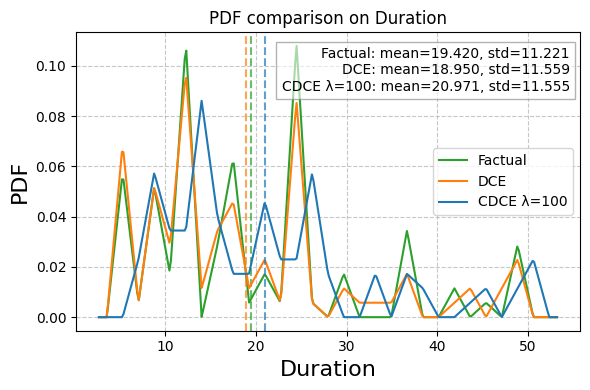

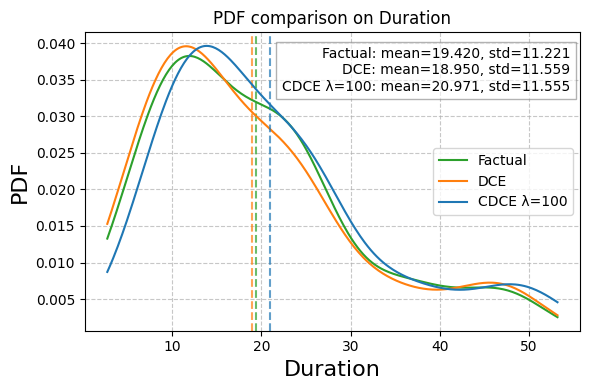

In [40]:
from utils.visualization import plot_pdf_column

plot_pdf_column(
    datasets=[factual, counterfactual, best_X_raw_mean_21_100],
    column_name="Duration",
    labels=["Factual", "DCE", "CDCE λ=100"],
    # mean=mean["Duration"],     
    # std=std["Duration"],       
    explain_columns=explain_columns,
    use_smoothing=False,
    colors=["tab:green", "tab:orange", "tab:blue"]
)

plot_pdf_column(
    datasets=[factual, counterfactual, best_X_raw_mean_21_100],
    column_name="Duration",
    labels=["Factual", "DCE", "CDCE λ=100"],
    # mean=mean["Duration"],
    # std=std["Duration"],
    explain_columns=explain_columns,
    use_smoothing=True,
    colors=["tab:green", "tab:orange", "tab:blue"]        
)


Penalty decreases monotonically to near zero with iterations; Q1 and Q2 on the right axis remain at a low level synchronously (and continue to decrease), indicating that the distribution alignment (SWD) on the X side and target alignment (WD) performance are not sacrificed while satisfying the constraints.

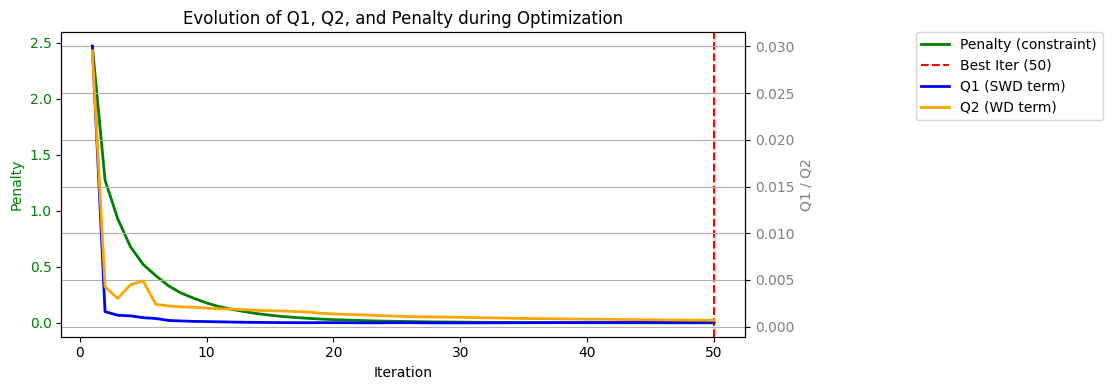

In [26]:
from importlib import reload
import explainers.dce_v2
reload(explainers.dce_v2)

from explainers.dce_v2 import DCEWithConstraints
explainer_MeanConstraint_21_100.plot_optimization_trace()

## 2. Does not compromise the proximity to `X_prime` and `y_target`

In [104]:
# ================== x  Wasserstein ==================
set_seed(42)
dist_unc = np.sqrt(explainer.swd.distance(X_s, X_t, explainer.delta)[0].item())
print(f"SWD (unconstrained vs factual): {dist_unc:.6f}")
dist_con = np.sqrt(explainer.swd.distance(best_X_MeanConstraint_21_100, X_t, explainer.delta)[0].item())
print(f"SWD (constrained vs factual):   {dist_con:.6f}")

# ================== y  Wasserstein ==================
y_constr = explainer_MeanConstraint_21_100.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(cf_y, y_target, delta=delta)[0].item())
dist_y_lsc_strict = np.sqrt(explainer.wd.distance(y_constr, y_target, delta=delta)[0].item())

print(f"WD (unconstrained vs factual): {dist_y:.4f}")
print(f"WD (constrained vs target): {dist_y_lsc_strict:.4f}")

SWD (unconstrained vs factual): 0.042136
SWD (constrained vs factual):   0.024303
WD (unconstrained vs factual): 0.0682
WD (constrained vs target): 0.0292


In [105]:
metrics_df = pd.DataFrame({
    "seed": [seed],
    "X_SWD_mean_constraint": [float(dist_con)],
    "Y_WD_mean_constraint": [float(dist_y_lsc_strict)]
})

with pd.ExcelWriter(
    save_path,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

After adding the mean constraint, the distribution of y and the proportion of good/bad under the 0.5 threshold are almost consistent with the unconstrained case, indicating that the algorithm maintains the matching degree to y while satisfying the constraint.

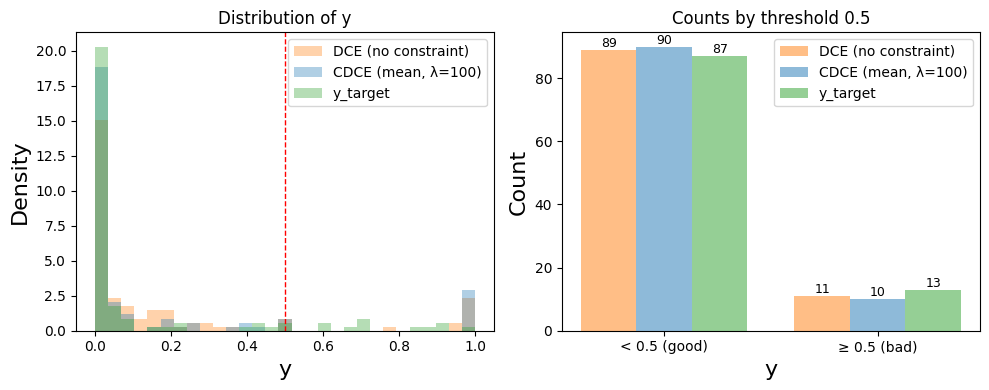

In [3]:
# ===== Read Excel files =====
save_dir = "germancredit"

factual_excel = pd.read_excel(
    os.path.join(save_dir, "factual.xlsx"),
    sheet_name="factual"
)

counterfactual_excel = pd.read_excel(
    os.path.join(save_dir, "counterfactual.xlsx"),
    sheet_name="counterfactual"
)

best_X_raw_mean_21_100_excel = pd.read_excel(
    os.path.join(save_dir, "mean_constraint_21_100.xlsx"),
    sheet_name="counterfactual"
)

# ===== Extract three groups of y from the Excel DataFrames already loaded =====

# Constrained DCE
y_constr = best_X_raw_mean_21_100_excel["y_cf_pred"].values

# Unconstrained DCE
y_unconstr = counterfactual_excel["y_cf_pred"].values

# target
y_tgt = factual_excel["y_target"].values


# ===== Continuous distribution comparison (histogram with threshold line) =====
bins = np.linspace(0, 1, 30)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(y_unconstr, bins=bins, density=True, alpha=0.35, label="DCE (no constraint)", color="tab:orange")
axes[0].hist(y_constr,   bins=bins, density=True, alpha=0.35, label="CDCE (mean, λ=100)", color="tab:blue")
axes[0].hist(y_tgt,      bins=bins, density=True, alpha=0.35, label="y_target", color="tab:green")
axes[0].axvline(0.5, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribution of y")
axes[0].set_xlabel("y",fontsize=16)
axes[0].set_ylabel("Density",fontsize=16)
axes[0].legend()

# ===== Bar chart of good/bad under 0.5 threshold =====
thr = 0.5

def counts(arr, t=0.5):
    return int((arr < t).sum()), int((arr >= t).sum())

u_bad, u_good = counts(y_unconstr, thr)
c_bad, c_good = counts(y_constr,   thr)
t_bad, t_good = counts(y_tgt,      thr)

cats = ["< 0.5 (good)", "≥ 0.5 (bad)"]
x = np.arange(2)
w = 0.26

axes[1].bar(x - w, [u_bad, u_good], width=w, alpha=0.5,label="DCE (no constraint)", color="tab:orange")
axes[1].bar(x,     [c_bad, c_good], width=w, alpha=0.5,label="CDCE (mean, λ=100)", color="tab:blue")
axes[1].bar(x + w, [t_bad, t_good], width=w, alpha=0.5,label="y_target", color="tab:green")

for i, v in enumerate([u_bad, u_good]):
    axes[1].text(x[i] - w, v, str(v), ha="center", va="bottom", fontsize=9)

for i, v in enumerate([c_bad, c_good]):
    axes[1].text(x[i], v, str(v), ha="center", va="bottom", fontsize=9)

for i, v in enumerate([t_bad, t_good]):
    axes[1].text(x[i] + w, v, str(v), ha="center", va="bottom", fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(cats)
axes[1].set_title("Counts by threshold 0.5")
axes[1].set_xlabel("y",fontsize=16)
axes[1].set_ylabel("Count",fontsize=16)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Effectiveness of the recovery algorithm

Currently, the optimization has iterated 50 times and does not meet the requirements. Try the mean recovery algorithm to fine-tune the mean value to above 21.

**Threshold method (θ=0.5)** : Label samples where the labels of `y_cf` and `y_target` are inconsistent under the threshold of 0.5 as recovery candidates, and delete the samples with the greatest impact on mean deviation from these candidates; in the current result, **dropping 1** sample is sufficient to complete the repair, and the repair is successful.

In [113]:
import torch
from explainers.recovery.RecoveryManager import RecoveryManager
from explainers.recovery.Evaluator import Evaluator  


# === 1. Initialize RecoveryManager (mean constraint) ===
recovery_config = [
    {"type": "mean", "bounds": {"Duration": (21, 1000)}, "priority": 0}
]
rm = RecoveryManager(feature_names=explain_columns, configs=recovery_config, verbose=True)

# === 2. Generate R_mask (use threshold mode to determine which need to be recovered) ===
evaluator = Evaluator(mode="threshold", theta=0.5)   
y_tgt = y_target.detach().cpu().view(-1)  
y_cf  = explainer_MeanConstraint_21_100.model(best_X_MeanConstraint_21_100).detach().cpu().view(-1)

R_mask, G_mask = evaluator.evaluate(y_target=y_tgt, y_cf=y_cf)
print(f"[threshold=0.5] Items to retrieve: {int(R_mask.sum())} / {R_mask.numel()}")

# === 3. Run Recovery (execute on original dimensions) ===
X_cf_tensor = torch.from_numpy(best_X_raw_mean_21_100[explain_columns].to_numpy()).float()
X_recovered, report = rm.run(X_cf_tensor, R_mask.bool())

# === 4. Print the dropped indices ===
dropped_idx = []
for rec in rm.recoveries:   
    if rec[1] == "mean":   
        mean_recovery = rec[2]
        dropped_idx = mean_recovery.last_dropped_indices
        break

if dropped_idx:
    print(f"\nNumber of dropped points: {len(dropped_idx)}")
    print("List of dropped indices:", dropped_idx)
else:
    print("\nNo points were dropped.")

[threshold=0.5] Items to retrieve: 23 / 100
[MeanRecovery] Duration success: mean=21.109 ∈ [21, 1000] (dropped 1)

Number of dropped points: 1
List of dropped indices: [93]


**Distance method (τ=0.05)** : For each counterfactual sample y_cf, calculate the transport matrix between it and the target sample set y_target through the Optimal Transport (OT) algorithm, select the y_target with the largest weight in each row as the matching object, label samples with `|y_cf − y_target| > 0.05` as recovery candidates, and delete the samples that contribute the most to the mean deviation from the candidates. The current results show that only 1 sample needs to be deleted to complete the repair, and the mean value meets the preset requirements after repair.

In [116]:
# === 3. Generate R_mask using distance mode (samples with |y_cf - y_target| > 0.01 are considered to need recovery) ===
evaluator = Evaluator(mode="distance", tau=0.01)  
y_tgt = explainer_MeanConstraint_21_100.y_prime.detach().cpu().view(-1)  
y_cf  = explainer_MeanConstraint_21_100.model(best_X_MeanConstraint_21_100).detach().cpu().view(-1)

R_mask, G_mask = evaluator.evaluate(y_target=y_tgt, y_cf=y_cf)
print(f"[distance=0.05] Items to retrieve : {int(R_mask.sum())} / {R_mask.numel()}")

# === 4. Run Recovery (execute on original dimensions) ===
X_cf_tensor = torch.from_numpy(best_X_raw_mean_21_100[explain_columns].to_numpy()).float()
X_recovered, report = rm.run(X_cf_tensor, R_mask.bool())

# === 5. Print the dropped indices ===
dropped_idx = []
for rec in rm.recoveries:   
    if rec[1] == "mean":   
        mean_recovery = rec[2]
        dropped_idx = mean_recovery.last_dropped_indices
        break

if dropped_idx:
    print(f"\nNumber of dropped points: {len(dropped_idx)}")
    print("List of dropped indices:", dropped_idx)
else:
    print("\nNo points were dropped.")


[distance=0.05] Items to retrieve : 20 / 100
[MeanRecovery] Duration success: mean=21.109 ∈ [21, 1000] (dropped 1)

Number of dropped points: 1
List of dropped indices: [93]


# **std**
1. The constraint effectively suppresses fluctuations

2. Does not compromise the proximity to `X_prime` and `y_target`

3. If the upper bound of the standard deviation is still exceeded after iteration, the recovery algorithm can be adopted

## 1. Constraints effectively suppress fluctuations
To ensure that the **standard deviation of this feature in the counterfactual distribution does not exceed `2000`**, a **upper bound constraint on standard deviation** can be introduced for **Credit amount** through the constraint manager in `dce_v2`.

In [31]:
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager

# ==== Convert the upper bound of 2000 in original dimensions to normalized space ====
sigma_upper_raw_std_2000_100 = 2000.0
sigma_upper_norm_std_2000_100 = float(sigma_upper_raw_std_2000_100 / std["Credit amount"]) 

# 1. Constraint configuration: set an upper bound constraint on the std of Credit amount (normalized space)
configs_std_2000_100 = [
    {"type": "std", "bounds": {"Credit amount": sigma_upper_norm_std_2000_100}, "lambda": 100}
]

cm_credit_std_2000_100 = ConstraintManager(configs=configs_std_2000_100, feature_names=explain_columns)
set_seed(42)
# 2. Initialize DCEWithConstraints and bind the manager
explainer_credit_std_2000_100 = DCEWithConstraints(
    model=model,
    df_X=df_explain,
    explain_columns=explain_columns,
    y_target=y_target,
    lr=1e-1,
    n_proj=N,
    delta=delta,
    constraint_manager=cm_credit_std_2000_100  
)

# 3. Execute optimization
set_seed(42)
explainer_credit_std_2000_100.optimize(
    U_1=0.5,
    U_2=0.3,
    l=0.2,
    r=1,
    max_iter=50,
    tau=1e3
)

# 4. Extract results after iteration completion
best_X_credit_std_2000_100 = explainer_credit_std_2000_100.best_X
best_y_credit_std_2000_100 = explainer_credit_std_2000_100.best_y


INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0295, term1=0.0304, term2=0.0295, penalty=0.26261237263679504
INFO:root:U_1-Qu_upper=0.42430458624718337, U_2-Qv_upper=0.21489312381530853
INFO:root:eta=0.7444941189109274, l=0.278, r=1
INFO:root:Iter 2: Q=0.0791, term1=0.0016, term2=0.0042, penalty=0.0756164938211441
INFO:root:U_1-Qu_upper=0.4897091729489458, U_2-Qv_upper=0.21990021818209848
INFO:root:eta=0.7762600671414236, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=0.0347, term1=0.0011, term2=0.0032, penalty=0.03201824426651001
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23019013710814365
INFO:root:eta=0.7837721888879854, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=0.0168, term1=0.0008, term2=0.0028, penalty=0.014494556002318859
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23663853966623355
INFO:root:eta=0.7906777240991479, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=0

In [32]:
from utils.data_transform import recover_original_df, column_stats

df_norm_credit_std_2000_100, df_raw_credit_std_2000_100 = recover_original_df(
    best_X=explainer_credit_std_2000_100.best_X,
    explain_columns=explain_columns,
    mean=mean,
    std=std
)

stats_credit_std_2000_100 = column_stats(
    df_norm_credit_std_2000_100,
    df_raw_credit_std_2000_100,
    "Credit amount"
)
print(f"std (normalized) = {stats_credit_std_2000_100['std_norm']:.4f}")
print(f"std (original)   = {stats_credit_std_2000_100['std_raw']:.4f}")


[Credit amount] normalized: mean=-0.2034, std=0.6903
[Credit amount] original  : mean=2771.0460, std=2000.5989
std (normalized) = 0.6903
std (original)   = 2000.5989


In [33]:
col = "Credit amount"
print("Factual   ddof0/1:", factual[col].std(ddof=0), factual[col].std(ddof=1))
print("CF(noc)   ddof0/1:", counterfactual[col].std(ddof=0), counterfactual[col].std(ddof=1))

Factual   ddof0/1: 2127.6099026607294 2138.3284082940045
CF(noc)   ddof0/1: 2155.3012150277277 2166.159224376993


In [117]:
save_dir = "germancredit"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "std_constraint_2000_100.xlsx")

# Use the raw-scale counterfactual results from the std constraint
cf_save_df = df_raw_credit_std_2000_100.copy()

# Prediction of counterfactual samples by the black-box model
y_cf_pred = model(
    torch.FloatTensor(best_X_credit_std_2000_100.detach().cpu().numpy())
)

# Last three columns: true y, predicted y of CF, target y
cf_save_df["y_true"] = y_true.values.reshape(-1)
cf_save_df["y_cf_pred"] = y_cf_pred.detach().cpu().numpy().reshape(-1)
cf_save_df["y_target"] = y_target.detach().cpu().numpy().reshape(-1)

with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
    cf_save_df.to_excel(
        writer,
        sheet_name="counterfactual",
        index=True
    )

Compare the distribution of the credit amount dimension among factual, DCE counterfactual, and counterfactual with mean constraint. The std constraint can indeed suppress the std of credit amount.

In [44]:

save_dir = "germancredit"

# Read factual
factual_excel = pd.read_excel(
    os.path.join(save_dir, "factual.xlsx"),
    sheet_name="factual",
    index_col=0
)

# Read no-constraint counterfactual
counterfactual_excel = pd.read_excel(
    os.path.join(save_dir, "counterfactual.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

# Read std-constraint counterfactual
std_constraint_excel = pd.read_excel(
    os.path.join(save_dir, "std_constraint_2000_100.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

# Keep only feature columns for plotting
factual = factual_excel[explain_columns]
counterfactual = counterfactual_excel[explain_columns]
df_raw_credit_std_2000_100 = std_constraint_excel[explain_columns]



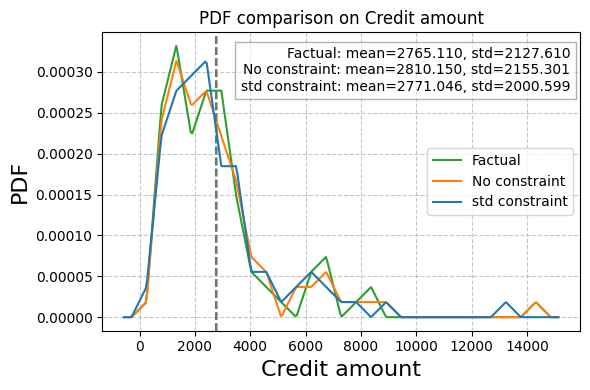

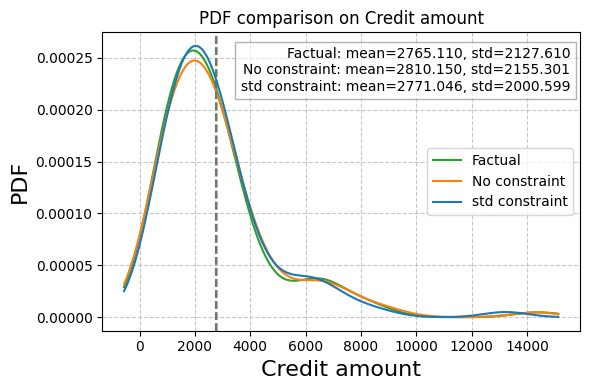

In [45]:
from utils.visualization import plot_pdf_column

plot_pdf_column(
    datasets=[factual, counterfactual, df_raw_credit_std_2000_100],
    column_name="Credit amount",
    labels=["Factual", "No constraint", "std constraint"],
    explain_columns=explain_columns,
    use_smoothing=False,
    colors=["tab:green", "tab:orange", "tab:blue"]
)

plot_pdf_column(
    datasets=[factual, counterfactual, df_raw_credit_std_2000_100],
    column_name="Credit amount",
    labels=["Factual", "No constraint", "std constraint"],
    explain_columns=explain_columns,
    use_smoothing=True,
    colors=["tab:green", "tab:orange", "tab:blue"]
)

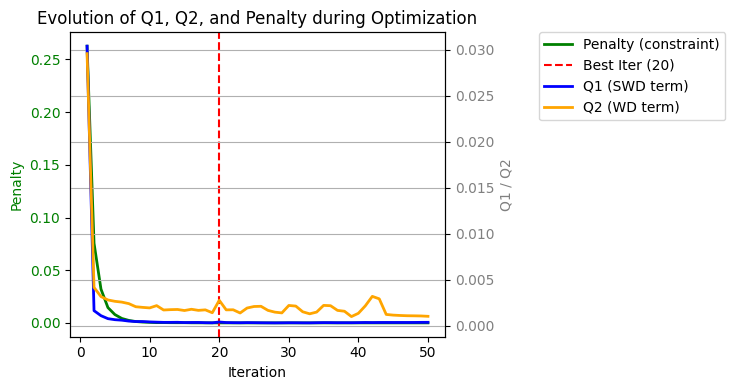

In [35]:
from importlib import reload
import explainers.dce_v2

from explainers.dce_v2 import DCEWithConstraints

explainer_credit_std_2000_100.plot_optimization_trace(figsize=(6, 4))

## 2. Does not compromise the proximity to `X_prime` and `y_target`

In [122]:
# ================== x Wasserstein ==================
set_seed(42)
dist_x_unc = np.sqrt(explainer.swd.distance(X_s, X_t, explainer.delta)[0].item())
print(f"SWD (unconstrained vs factual): {dist_x_unc:.6f}")
dist_x_con = np.sqrt(explainer.swd.distance(best_X_credit_std_2000_100, X_t, explainer.delta)[0].item())
print(f"SWD (constrained vs factual):   {dist_x_con:.6f}")

# ================== y Wasserstein ==================
# y_constr = explainer_MeanConstraint_21_100.best_y.clone().detach()
y_constr = explainer_credit_std_2000_100.best_y.clone().detach()

dist_y_unc = np.sqrt(explainer.wd.distance(cf_y, y_target, delta=delta)[0].item())
dist_y_std = np.sqrt(explainer.wd.distance(y_constr, y_target, delta=delta)[0].item())

print(f"WD (unconstrained vs factual): {dist_y_unc:.4f}")
print(f"WD (constrained vs factual): {dist_y_std:.4f}")

SWD (unconstrained vs factual): 0.042136
SWD (constrained vs factual):   0.020541
WD (unconstrained vs factual): 0.0682
WD (constrained vs factual): 0.0553


In [123]:
save_path = os.path.join(save_dir, "std_constraint_2000_100.xlsx")

metrics_df = pd.DataFrame({
    "seed": [seed],
    "X_SWD_std_constraint": [float(dist_x_con)],
    "Y_WD_std_constraint": [float(dist_y_std)]
})

with pd.ExcelWriter(
    save_path,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

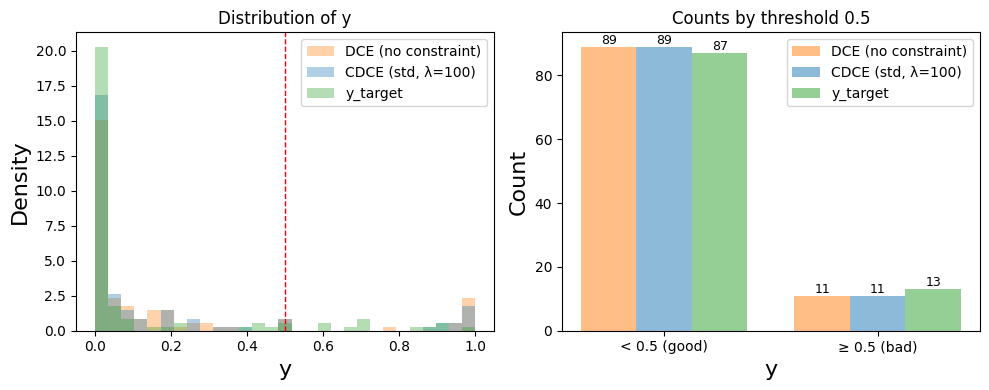

In [4]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ===== Read Excel files =====
save_dir = "germancredit"

factual_excel = pd.read_excel(
    os.path.join(save_dir, "factual.xlsx"),
    sheet_name="factual"
)

counterfactual_excel = pd.read_excel(
    os.path.join(save_dir, "counterfactual.xlsx"),
    sheet_name="counterfactual"
)

std_constraint_excel = pd.read_excel(
    os.path.join(save_dir, "std_constraint_2000_100.xlsx"),
    sheet_name="counterfactual"
)

# ===== Extract three groups of y from Excel =====
y_constr   = std_constraint_excel["y_cf_pred"].values
y_unconstr = counterfactual_excel["y_cf_pred"].values
y_tgt      = factual_excel["y_target"].values

# ===== Continuous distribution comparison (histogram with threshold line) =====
bins = np.linspace(0, 1, 30)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(y_unconstr, bins=bins, density=True, alpha=0.35, label="DCE (no constraint)", color="tab:orange")
axes[0].hist(y_constr,   bins=bins, density=True, alpha=0.35, label="CDCE (std, λ=100)", color="tab:blue")
axes[0].hist(y_tgt,      bins=bins, density=True, alpha=0.35, label="y_target", color="tab:green")
axes[0].axvline(0.5, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Distribution of y")
axes[0].set_xlabel("y",fontsize=16)
axes[0].set_ylabel("Density",fontsize=16)
axes[0].legend()

# ===== Bar chart of good/bad under 0.5 threshold =====
thr = 0.5

def counts(arr, t=0.5):
    return int((arr < t).sum()), int((arr >= t).sum())

u_bad, u_good = counts(y_unconstr, thr)
c_bad, c_good = counts(y_constr,   thr)
t_bad, t_good = counts(y_tgt,      thr)

cats = ["< 0.5 (good)", "≥ 0.5 (bad)"]
x = np.arange(2)
w = 0.26

axes[1].bar(x - w, [u_bad, u_good], width=w, alpha=0.5, label="DCE (no constraint)", color="tab:orange")
axes[1].bar(x,     [c_bad, c_good], width=w, alpha=0.5, label="CDCE (std, λ=100)", color="tab:blue")
axes[1].bar(x + w, [t_bad, t_good], width=w, alpha=0.5, label="y_target", color="tab:green")

for i, v in enumerate([u_bad, u_good]):
    axes[1].text(x[i] - w, v, str(v), ha="center", va="bottom", fontsize=9)

for i, v in enumerate([c_bad, c_good]):
    axes[1].text(x[i], v, str(v), ha="center", va="bottom", fontsize=9)

for i, v in enumerate([t_bad, t_good]):
    axes[1].text(x[i] + w, v, str(v), ha="center", va="bottom", fontsize=9)

axes[1].set_xticks(x)
axes[1].set_xticklabels(cats)
axes[1].set_title("Counts by threshold 0.5")
axes[1].set_xlabel("y",fontsize=16)
axes[1].set_ylabel("Count",fontsize=16)
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Effectiveness of the recovery algorithm

Currently, the optimization has iterated 50 times, and the std does not strictly meet the requirements. Try the mean recovery algorithm to fine-tune the std to below 2000.

First, adopt the **threshold method (0.5)** : When judging unreversed samples by 0.5, `R_mask` is all `False`.

In [38]:
import torch
from explainers.recovery.RecoveryManager import RecoveryManager
from explainers.recovery.Evaluator import Evaluator

# === 1) RecoveryManager: STD upper bound (original dimensions) ===
recovery_config = [
    {"type": "std", "bounds": {"Credit amount": 2000.0}, "priority": 0}
]
rm = RecoveryManager(feature_names=explain_columns, configs=recovery_config, verbose=True)

# === 2) Evaluator: Threshold method (theta=0.5) ===
evaluator = Evaluator(mode="threshold", theta=0.5)
R_mask, G_mask = evaluator.evaluate(
    y_target=explainer_credit_std_2000_100.y_prime.detach().cpu().view(-1),
    y_cf=explainer_credit_std_2000_100.best_y.detach().cpu().view(-1)
)

# === 3) Run Recovery (execute on original dimensions) ===
X_cf_tensor = torch.from_numpy(df_raw_credit_std_2000_100[explain_columns].to_numpy()).float()
X_recovered, report = rm.run(X_cf_tensor, R_mask.bool())

print("Recovery report:", report)
print("Standard deviation of Credit amount after repair:",
      X_recovered[:, explain_columns.index("Credit amount")].std(unbiased=False).item())

# === 4) Print detailed information of dropped points ===
#  Directly retrieve records from StdRecovery
std_recovery = rm.recoveries[0][2]   
dropped_idx = std_recovery.last_dropped_indices

if dropped_idx:
    print(f"\nNumber of candidates (R=True): {int(R_mask.sum())}, Actual number of dropped points: {len(dropped_idx)}")
    y_cf = explainer_credit_std_2000_100.best_y.detach().cpu().view(-1)
    y_tgt = explainer_credit_std_2000_100.y_prime.detach().cpu().view(-1)

    for idx in dropped_idx:
        cf_val = df_raw_credit_std_2000_100.iloc[idx]["Credit amount"]
        print(f"idx={idx:3d}  CF={cf_val:.4f}  y_cf={y_cf[idx].item():.4f}  y_target={y_tgt[idx].item():.4f}")
else:
    print("\nNo points were dropped.")

[StdRecovery] Credit amount success: std=1704.890 ≤ 2000.0 (dropped 2)
Recovery report: {'Credit amount': {'std': 'success'}}
Standard deviation of Credit amount after repair: 1704.8900146484375

Number of candidates (R=True): 24, Actual number of dropped points: 2
idx= 26  CF=480.9813  y_cf=0.0179  y_target=0.6865
idx= 57  CF=13233.4549  y_cf=0.9996  y_target=0.0048


Then adopt the **distance method (0.05)** : For each counterfactual sample y_cf, calculate the transport matrix between it and the target sample set y_target through the Optimal Transport (OT) algorithm, select the y_target with the largest weight in each row as the matching object, and label samples with `|y_cf − y_target| > 0.05` as recovery candidates. We find the two values (the maximum and minimum) from the candidate set and delete them simultaneously each time. This effectively offsets the mean deviation caused by one-sided deletion, thereby reducing the standard deviation while maintaining the stability of the overall mean.

In [39]:
# # === Generate R_mask using distance mode (samples with |y_cf - y_target| > 0.05 need to be recovered) ===
evaluator = Evaluator(mode="distance", tau=0.01)
y_tgt = explainer_credit_std_2000_100.y_prime.detach().cpu().view(-1)  
y_cf  = explainer_credit_std_2000_100.model(
            explainer_credit_std_2000_100.best_X
        ).detach().cpu().view(-1)  

R_mask, G_mask = evaluator.evaluate(y_target=y_tgt, y_cf=y_cf)

# === 4. Run Recovery (on original dimensions; DataFrame -> Tensor) ===
X_cf_tensor = torch.from_numpy(df_raw_credit_std_2000_100[explain_columns].to_numpy()).float()
X_recovered, report = rm.run(X_cf_tensor, R_mask.bool())

print("Recovery report:", report)
print("Standard deviation of Credit amount after repair:",
      X_recovered[:, explain_columns.index("Credit amount")].std(unbiased=False).item())

# === 5. Print detailed information of dropped points ===
# Directly get rm.recoveries[0][2], which is StdRecovery
std_recovery = rm.recoveries[0][2]
dropped_idx = std_recovery.last_dropped_indices

if dropped_idx:
    print(f"\nNumber of candidates (R=True): {int(R_mask.sum())}, Actual number of dropped points: {len(dropped_idx)}")
    for idx in dropped_idx:
        cf_val = df_raw_credit_std_2000_100.iloc[idx]["Credit amount"]
        fa_val = factual.iloc[idx]["Credit amount"] if "factual" in locals() else float("nan")
        print(f"idx={idx:3d}  CF={cf_val:.4f}  FA={fa_val:.4f}  "
              f"y_cf={y_cf[idx].item():.4f}  y_target={y_tgt[idx].item():.4f}")
else:
    print("\nNo points were dropped.")


[StdRecovery] Credit amount success: std=1977.467 ≤ 2000.0 (dropped 2)
Recovery report: {'Credit amount': {'std': 'success'}}
Standard deviation of Credit amount after repair: 1977.4666748046875

Number of candidates (R=True): 20, Actual number of dropped points: 2
idx= 40  CF=801.6854  FA=727.0000  y_cf=0.9576  y_target=0.0009
idx= 84  CF=6392.7402  FA=6681.0000  y_cf=0.9459  y_target=0.0000


# **LSC**

The original DCE optimization objective only focuses on the OT distance (X, y distribution) and does not have additional constraints on the structural nature of Credit~Duration. LSCConstraint —— its role is to "hold onto" this linear structure during optimization, so that the generated counterfactuals not only have a reasonable distribution but also comply with such business logic dependencies. We provide two modes (hinge and strict) to adapt to the needs of different business scenarios for constraint intensity.

In [16]:
corr_matrix = df[explain_columns].corr(numeric_only=True)

pairs = []

for i in range(len(explain_columns)):
    for j in range(i + 1, len(explain_columns)):
        col1 = explain_columns[i]
        col2 = explain_columns[j]
        corr = corr_matrix.loc[col1, col2]
        pairs.append({
            "feature_1": col1,
            "feature_2": col2,
            "corr": corr,
            "abs_corr": abs(corr)
        })

pair_corr_df = pd.DataFrame(pairs).sort_values("abs_corr", ascending=False)

print(pair_corr_df.head(20))

           feature_1         feature_2      corr  abs_corr
33     Credit amount          Duration  0.624984  0.624984
18               Job     Credit amount  0.285385  0.285385
19               Job          Duration  0.210910  0.210910
23           Housing     Credit amount -0.171585  0.171585
0                Age               Sex  0.161694  0.161694
34     Credit amount           Purpose -0.151720  0.151720
24           Housing          Duration -0.137434  0.137434
26   Saving accounts  Checking account  0.125667  0.125667
2                Age           Housing -0.112051  0.112051
15               Job           Housing -0.101939  0.101939
22           Housing  Checking account  0.097742  0.097742
12               Sex     Credit amount  0.093482  0.093482
25           Housing           Purpose  0.086839  0.086839
35          Duration           Purpose -0.083459  0.083459
13               Sex          Duration  0.081432  0.081432
27   Saving accounts     Credit amount -0.077929  0.0779

## Fitting the relationship between duration and credit amount on the training set

In the normalized space, the relationship fitted on the training set (800 samples) is **Duration ≈ 0.63 × Credit amount**, with an MSE≈0.6, indicating that there is a certain linear structure between the two; therefore, it is reasonable to explore structural constraints on these two variables. (If the MSE is close to 1, it indicates that there is almost no interpretable linear relationship between the two variables in the normalized space). First, plot a chart to show the comparison of the linear relationship between Credit and Duration among the training set (800 samples), factual samples of the explanation set (100 samples), and original DCE counterfactuals (100 samples).

Linear model: Duration = 0.6264 * Credit amount + 0.0000
MSE on training data: 0.6069
MSE on df_explain data: 0.5883
MSE on X_s (counterfactuals): 0.6555


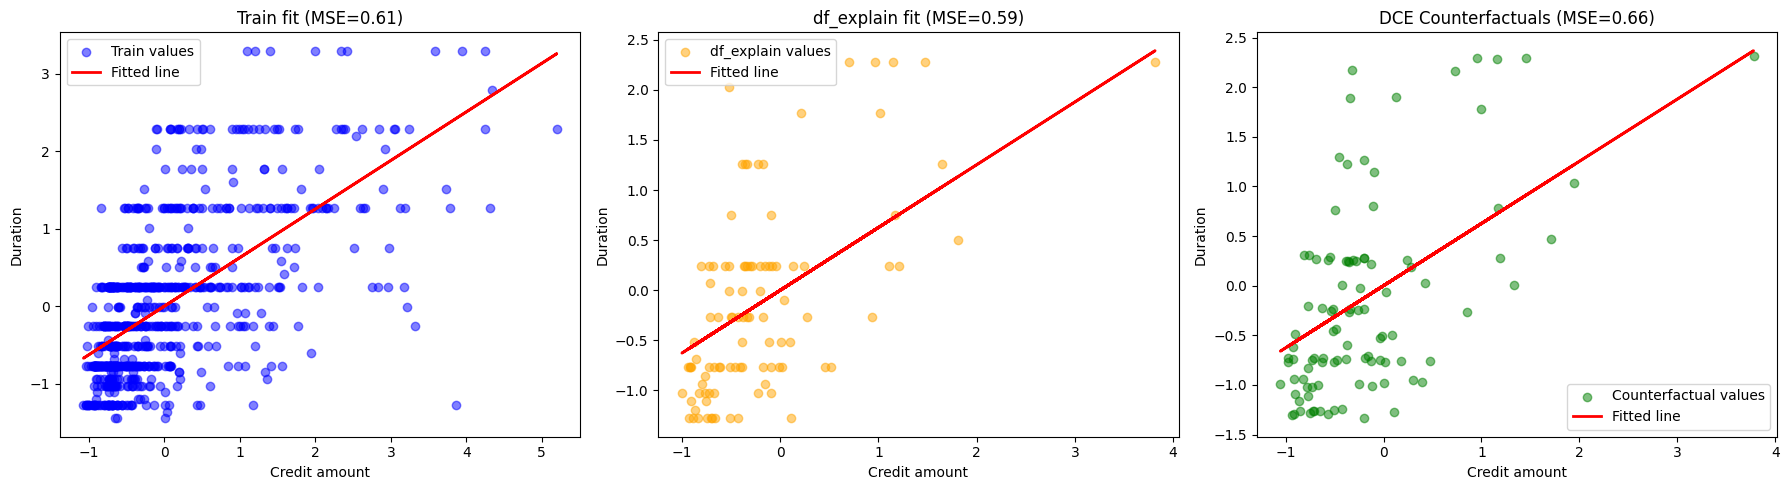

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Step 1. Fit linear model on training set: Credit amount → Duration
X_lin_train = X_train[["Credit amount"]].values.reshape(-1, 1)
y_lin_train = X_train["Duration"].values

lin_reg = LinearRegression()
lin_reg.fit(X_lin_train, y_lin_train)

y_pred_train = lin_reg.predict(X_lin_train)
mse_train = mean_squared_error(y_lin_train, y_pred_train)

coef = lin_reg.coef_[0]
intercept = lin_reg.intercept_
print(f"Linear model: Duration = {coef:.4f} * Credit amount + {intercept:.4f}")
print(f"MSE on training data: {mse_train:.4f}")

# Step 2. Evaluate on df_explain
X_lin_explain = df_explain[["Credit amount"]].values.reshape(-1, 1)
y_lin_explain = df_explain["Duration"].values
y_pred_explain = lin_reg.predict(X_lin_explain)
mse_explain = mean_squared_error(y_lin_explain, y_pred_explain)
print(f"MSE on df_explain data: {mse_explain:.4f}")

# Step 3. Evaluate on X_s generated by DCE
idx_credit = explain_columns.index("Credit amount")
idx_duration = explain_columns.index("Duration")

X_s_credit = X_s[:, idx_credit].detach().cpu().numpy().reshape(-1, 1)
y_s_true_duration = X_s[:, idx_duration].detach().cpu().numpy()
y_s_pred_duration = lin_reg.predict(X_s_credit)
mse_s = mean_squared_error(y_s_true_duration, y_s_pred_duration)
print(f"MSE on X_s (counterfactuals): {mse_s:.4f}")

# Step 4. Compare three plots side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left plot: Training set
axes[0].scatter(X_lin_train, y_lin_train, color="blue", alpha=0.5, label="Train values")
axes[0].plot(X_lin_train, y_pred_train, color="red", linewidth=2, label="Fitted line")
axes[0].set_xlabel("Credit amount")
axes[0].set_ylabel("Duration")
axes[0].set_title(f"Train fit (MSE={mse_train:.2f})")
axes[0].legend()

# Middle plot: df_explain
axes[1].scatter(X_lin_explain, y_lin_explain, color="orange", alpha=0.5, label="df_explain values")
axes[1].plot(X_lin_explain, y_pred_explain, color="red", linewidth=2, label="Fitted line")
axes[1].set_xlabel("Credit amount")
axes[1].set_ylabel("Duration")
axes[1].set_title(f"df_explain fit (MSE={mse_explain:.2f})")
axes[1].legend()

# Right plot: Counterfactual samples generated by DCE
axes[2].scatter(X_s_credit, y_s_true_duration, color="green", alpha=0.5, label="Counterfactual values")
axes[2].plot(X_s_credit, y_s_pred_duration, color="red", linewidth=2, label="Fitted line")
axes[2].set_xlabel("Credit amount")
axes[2].set_ylabel("Duration")
axes[2].set_title(f"DCE Counterfactuals (MSE={mse_s:.2f})")
axes[2].legend()

plt.tight_layout()
plt.show()

## Mode 1: hinge mode
Instead of attempting to "absolutely fit the linear structure", it only gently suppresses points that significantly deviate from the structure, preserving the inherent volatility of the data. We take the **MSE (≈0.6)** fitted from **Credit → Duration** on the training set as the tolerance threshold for hinge.

In [33]:
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager

# ================== 1. Define LSC (hinge) constraint ==================
configs_hinge = [
    {
        "type": "lsc",
        "relation": {
            "Duration": (["Credit amount"], [0.6264], 0.0)
        },
        "lambda": 1,
        "mode": "hinge",
        "tolerance": mse_train   #   Directly use the training MSE calculated in the first section
    }
]

#  Ensure the order is consistent with df_explain.columns
feature_names = list(df_explain.columns)
constraint_manager_hinge = ConstraintManager(configs=configs_hinge, feature_names=feature_names)

# ================== 2. Initialize Explainer ==================
set_seed(42)
explainer_lsc_hinge = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1, 
    n_proj=N,
    delta=delta,
    constraint_manager=constraint_manager_hinge
)

# ================== 3. Optimize to generate counterfactuals ==================
set_seed(42)
explainer_lsc_hinge.optimize(
    U_1=0.5, 
    U_2=0.3, 
    l=0.2, 
    r=1, 
    max_iter=50, 
    tau=10
)

X_s_lsc_hinge = explainer_lsc_hinge.best_X[:, explainer_lsc_hinge.explain_indices].clone().detach()
print(" Generated CFs with LSC (hinge). Shape:", X_s_lsc_hinge.shape)

# ================== 4. Evaluate LSC (hinge)  ==================
idx_credit = explain_columns.index("Credit amount")
idx_duration = explain_columns.index("Duration")

X_s_credit_lsc_hinge = X_s_lsc_hinge[:, idx_credit].cpu().numpy().reshape(-1, 1)
y_s_true_duration_lsc_hinge = X_s_lsc_hinge[:, idx_duration].cpu().numpy()
y_s_pred_duration_lsc_hinge = lin_reg.predict(X_s_credit_lsc_hinge)
mse_s_lsc_hinge = mean_squared_error(y_s_true_duration_lsc_hinge, y_s_pred_duration_lsc_hinge)

print(f"MSE on X_s (DCE no constraint): {mse_s:.4f}")       
print(f"MSE on X_s_lsc (hinge):        {mse_s_lsc_hinge:.4f}")


INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0223, term1=0.0004, term2=0.0223, penalty=0.25790002942085266
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.1141414505665014
INFO:root:eta=0.8587499633015769, l=0.278, r=1
INFO:root:Iter 2: Q=0.2470, term1=0.0004, term2=0.0132, penalty=0.2355567216873169
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.14636490510491923
INFO:root:eta=0.8365080457631, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=0.2242, term1=0.0004, term2=0.0109, penalty=0.21492916345596313
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.16280503512730066
INFO:root:eta=0.8315221404852964, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=0.2039, term1=0.0004, term2=0.0093, penalty=0.19605766236782074
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.16987349611363473
INFO:root:eta=0.8347592193491593, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=0.1861, term1=0.0005, term2=0.0085, p

 Generated CFs with LSC (hinge). Shape: torch.Size([100, 9])
MSE on X_s (DCE no constraint): 0.6555
MSE on X_s_lsc (hinge):        0.3030


In [36]:
import os
import pandas as pd
import torch

save_dir = "germancredit"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "lsc_hinge_constraint.xlsx")

# Convert LSC counterfactual X from normalized scale to original scale
cf_save_df = pd.DataFrame(
    explainer_lsc_hinge.best_X.detach().cpu().numpy(),
    columns=explain_columns
)

cf_save_df = cf_save_df * std[explain_columns] + mean[explain_columns]

# Prediction of LSC counterfactual samples by the black-box model
y_cf_pred = model(
    torch.FloatTensor(explainer_lsc_hinge.best_X.detach().cpu().numpy())
)

# Last three columns: true y, predicted y of CF, target y
cf_save_df["y_true"] = y_true.values.reshape(-1)
cf_save_df["y_cf_pred"] = y_cf_pred.detach().cpu().numpy().reshape(-1)
cf_save_df["y_target"] = y_target.detach().cpu().numpy().reshape(-1)

with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
    cf_save_df.to_excel(
        writer,
        sheet_name="counterfactual",
        index=True
    )

Compared with the original DCE, the MSE of the generated samples significantly decreases after introducing LSC (hinge), indicating that the counterfactuals better comply with the linear structural constraints of Credit–Duration.

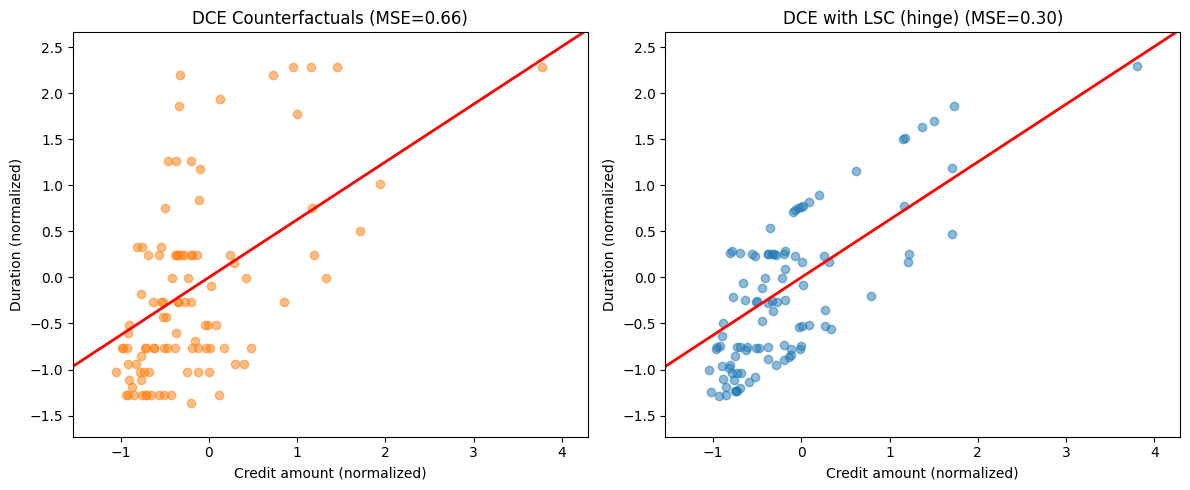

In [38]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

save_dir = "germancredit"

# ===== Read no-constraint CF and LSC hinge CF from Excel =====
counterfactual_excel = pd.read_excel(
    os.path.join(save_dir, "counterfactual.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

lsc_hinge_excel = pd.read_excel(
    os.path.join(save_dir, "lsc_hinge_constraint.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

# ===== Extract Credit amount and Duration from Excel, then normalize them =====
X_s_credit = (
    (counterfactual_excel["Credit amount"].values - mean["Credit amount"])
    / std["Credit amount"]
).reshape(-1, 1)

y_s_true_duration = (
    (counterfactual_excel["Duration"].values - mean["Duration"])
    / std["Duration"]
)

X_s_credit_lsc_hinge = (
    (lsc_hinge_excel["Credit amount"].values - mean["Credit amount"])
    / std["Credit amount"]
).reshape(-1, 1)

y_s_true_duration_lsc_hinge = (
    (lsc_hinge_excel["Duration"].values - mean["Duration"])
    / std["Duration"]
)

# ===== Recalculate MSE in normalized space =====
y_s_pred_duration = lin_reg.predict(X_s_credit)
y_s_pred_duration_lsc_hinge = lin_reg.predict(X_s_credit_lsc_hinge)

mse_s = mean_squared_error(y_s_true_duration, y_s_pred_duration)
mse_s_lsc_hinge = mean_squared_error(y_s_true_duration_lsc_hinge, y_s_pred_duration_lsc_hinge)

# ================== Plot comparison chart ==================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unify the range of horizontal and vertical axes
x_min = min(X_s_credit.min(), X_s_credit_lsc_hinge.min())
x_max = max(X_s_credit.max(), X_s_credit_lsc_hinge.max())
y_min = min(y_s_true_duration.min(), y_s_true_duration_lsc_hinge.min())
y_max = max(y_s_true_duration.max(), y_s_true_duration_lsc_hinge.max())

x_buffer = 0.1 * (x_max - x_min)
y_buffer = 0.1 * (y_max - y_min)

x_min, x_max = x_min - x_buffer, x_max + x_buffer
y_min, y_max = y_min - y_buffer, y_max + y_buffer

# ===== Fitted line covers the entire x range =====
x_line = np.linspace(x_min, x_max, 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

# Left plot: DCE without constraints
axes[0].scatter(X_s_credit, y_s_true_duration, color="tab:orange", alpha=0.5)
axes[0].plot(x_line, y_line, color="red", linewidth=2)
axes[0].set_xlabel("Credit amount (normalized)")
axes[0].set_ylabel("Duration (normalized)")
axes[0].set_title(f"DCE Counterfactuals (MSE={mse_s:.2f})")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

# Right plot: DCE + LSC (hinge)
axes[1].scatter(X_s_credit_lsc_hinge, y_s_true_duration_lsc_hinge, color="tab:blue", alpha=0.5)
axes[1].plot(x_line, y_line, color="red", linewidth=2)
axes[1].set_xlabel("Credit amount (normalized)")
axes[1].set_ylabel("Duration (normalized)")
axes[1].set_title(f"DCE with LSC (hinge) (MSE={mse_s_lsc_hinge:.2f})")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

Check the Wasserstein distance: To confirm that while improving the consistency of the linear structure, the counterfactual distribution remains close to the factual distribution without significant deviation.

In [34]:
# ================== X Wasserstein ==================
dist_X = np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())
dist_X_lsc_hinge = np.sqrt(explainer.swd.distance(X_s_lsc_hinge, X_t, delta)[0].item())

print(f"Wasserstein distance (X, Original DCE vs Factual): {dist_X:.4f}")
print(f"Wasserstein distance (X, LSC-hinge-DCE vs Factual): {dist_X_lsc_hinge:.4f}")

# ================== y Wasserstein ==================
y_lsc_hinge = explainer_lsc_hinge.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(cf_y, y_target, delta=delta)[0].item())
dist_y_lsc_hinge = np.sqrt(explainer.wd.distance(y_lsc_hinge, y_target, delta=delta)[0].item())

print(f"Wasserstein distance (y, Original DCE vs Factual): {dist_y:.4f}")
print(f"Wasserstein distance (y, LSC-hinge-DCE vs Factual): {dist_y_lsc_hinge:.4f}")

Wasserstein distance (X, Original DCE vs Factual): 0.0421
Wasserstein distance (X, LSC-hinge-DCE vs Factual): 0.0346
Wasserstein distance (y, Original DCE vs Factual): 0.0682
Wasserstein distance (y, LSC-hinge-DCE vs Factual): 0.0566


In [39]:
save_path = os.path.join(save_dir, "lsc_hinge_constraint.xlsx")

metrics_df = pd.DataFrame({
    "seed": [seed],
    "X_SWD_lsc_hinge": [float(dist_X_lsc_hinge)],
    "Y_WD_lsc_hinge": [float(dist_y_lsc_hinge)]
})

with pd.ExcelWriter(
    save_path,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

## Mode 2: strict mode
Simulate scenarios with strict linear structures to ensure that counterfactuals strictly comply with the preset causal relationships. Note/Warning: If the structural relationship itself is a pseudo-linear relationship with significant noise, strict mode may "overfit the structure".

In [40]:
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager

# ================== 1. Define constraints ==================
configs = [
    {
        "type": "lsc",
        "relation": {
            # Duration ≈ 0.6264 * Credit amount + 0.0
            "Duration": (["Credit amount"], [0.6264], 0.0)
        },
        "lambda": 1,
        "mode": "strict"
    }
]

# Pass in the global column name order to ensure consistency with df_explain.columns
feature_names = list(df_explain.columns)
constraint_manager = ConstraintManager(configs=configs, feature_names=feature_names)

# print("Explain columns:", explain_columns)
# print("All feature names:", feature_names)

# ================== 2. Initialize Explainer ==================
set_seed(42)
explainer_lsc_strict = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1, 
    n_proj=N,
    delta=delta,
    constraint_manager=constraint_manager
)

# ================== 3. Optimize to generate counterfactuals ==================
set_seed(42)
explainer_lsc_strict.optimize(     
    U_1=0.5, 
    U_2=0.3, 
    l=0.2, 
    r=1, 
    max_iter=50, 
    tau=10
)

X_s_lsc_strict = explainer_lsc_strict.best_X[:, explainer_lsc_strict.explain_indices].clone().detach()
# print("Generated CFs with LSC. Shape:", X_s_lsc.shape)

# ================== 4. Evaluate LSC CF ==================
idx_credit = explain_columns.index("Credit amount")
idx_duration = explain_columns.index("Duration")

X_s_credit_lsc_strict = X_s_lsc_strict[:, idx_credit].cpu().numpy().reshape(-1, 1)
y_s_true_duration_lsc_strict = X_s_lsc_strict[:, idx_duration].cpu().numpy()
y_s_pred_duration_lsc_strict = lin_reg.predict(X_s_credit_lsc_strict)
mse_s_lsc_strict = mean_squared_error(y_s_true_duration_lsc_strict, y_s_pred_duration_lsc_strict)

print(f"MSE on X_s (DCE no constraint): {mse_s:.4f}")       
print(f"MSE on X_s_lsc (DCE with LSC): {mse_s_lsc_strict:.4f}")


INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0224, term1=0.0004, term2=0.0224, penalty=0.5590121150016785
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.11394529126257719
INFO:root:eta=0.8589476577278259, l=0.278, r=1
INFO:root:Iter 2: Q=0.5408, term1=0.0004, term2=0.0132, penalty=0.529457688331604
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.14452567477434505
INFO:root:eta=0.8381018146040338, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=0.5105, term1=0.0004, term2=0.0110, penalty=0.5012447834014893
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.1620751911104855
INFO:root:eta=0.8320925250254081, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=0.4822, term1=0.0005, term2=0.0094, penalty=0.4742596447467804
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.16872259417979812
INFO:root:eta=0.8355962742437744, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=0.4561, term1=0.0005, term2=0.0087, pe

MSE on X_s (DCE no constraint): 0.6648
MSE on X_s_lsc (DCE with LSC): 0.0459


In [41]:

save_dir = "germancredit"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "lsc_strict_constraint.xlsx")

# Convert LSC strict counterfactual X from normalized scale to original scale
cf_save_df = pd.DataFrame(
    explainer_lsc_strict.best_X.detach().cpu().numpy(),
    columns=explain_columns
)

cf_save_df = cf_save_df * std[explain_columns] + mean[explain_columns]

# Prediction of LSC strict counterfactual samples by the black-box model
y_cf_pred = model(
    torch.FloatTensor(explainer_lsc_strict.best_X.detach().cpu().numpy())
)

# Last three columns: true y, predicted y of CF, target y
cf_save_df["y_true"] = y_true.values.reshape(-1)
cf_save_df["y_cf_pred"] = y_cf_pred.detach().cpu().numpy().reshape(-1)
cf_save_df["y_target"] = y_target.detach().cpu().numpy().reshape(-1)

with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
    cf_save_df.to_excel(
        writer,
        sheet_name="counterfactual",
        index=True
    )

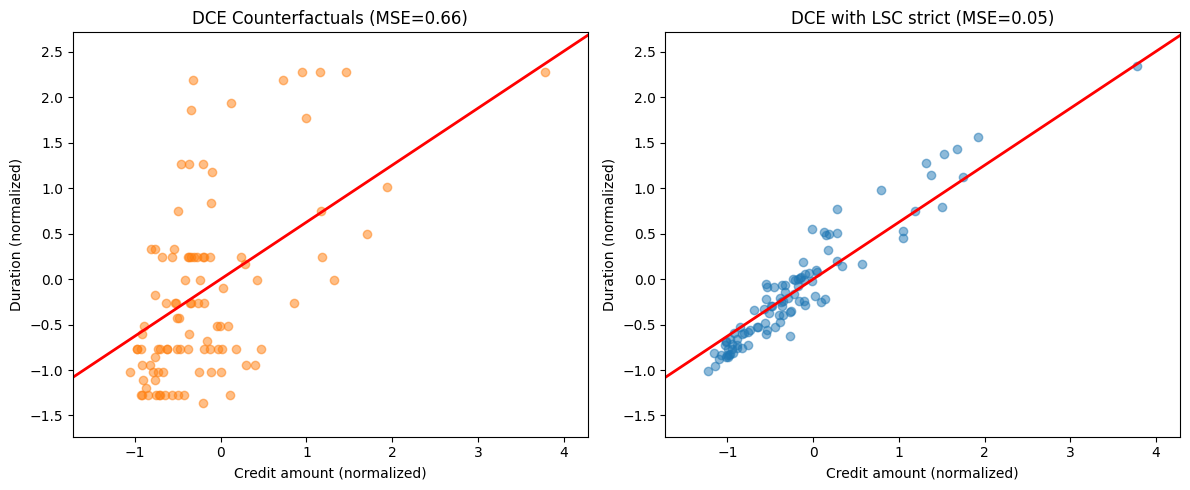

In [43]:

save_dir = "germancredit"

# ===== Read no-constraint CF and LSC strict CF from Excel =====
counterfactual_excel = pd.read_excel(
    os.path.join(save_dir, "counterfactual.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

lsc_strict_excel = pd.read_excel(
    os.path.join(save_dir, "lsc_strict_constraint.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

# ===== Extract Credit amount and Duration from Excel, then normalize them =====
X_s_credit = (
    (counterfactual_excel["Credit amount"].values - mean["Credit amount"])
    / std["Credit amount"]
).reshape(-1, 1)

y_s_true_duration = (
    (counterfactual_excel["Duration"].values - mean["Duration"])
    / std["Duration"]
)

X_s_credit_lsc_strict = (
    (lsc_strict_excel["Credit amount"].values - mean["Credit amount"])
    / std["Credit amount"]
).reshape(-1, 1)

y_s_true_duration_lsc_strict = (
    (lsc_strict_excel["Duration"].values - mean["Duration"])
    / std["Duration"]
)

# ===== Recalculate MSE in normalized space =====
y_s_pred_duration = lin_reg.predict(X_s_credit)
y_s_pred_duration_lsc_strict = lin_reg.predict(X_s_credit_lsc_strict)

mse_s = mean_squared_error(y_s_true_duration, y_s_pred_duration)
mse_s_lsc_strict = mean_squared_error(y_s_true_duration_lsc_strict, y_s_pred_duration_lsc_strict)

# ================== Plot comparison chart ==================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unify the range of horizontal and vertical axes
x_min = min(X_s_credit.min(), X_s_credit_lsc_strict.min())
x_max = max(X_s_credit.max(), X_s_credit_lsc_strict.max())
y_min = min(y_s_true_duration.min(), y_s_true_duration_lsc_strict.min())
y_max = max(y_s_true_duration.max(), y_s_true_duration_lsc_strict.max())

x_buffer = 0.1 * (x_max - x_min)
y_buffer = 0.1 * (y_max - y_min)

x_min, x_max = x_min - x_buffer, x_max + x_buffer
y_min, y_max = y_min - y_buffer, y_max + y_buffer

# ===== Fitted line covers the entire x range =====
x_line = np.linspace(x_min, x_max, 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

# Left plot: DCE without constraints
axes[0].scatter(X_s_credit, y_s_true_duration, color="tab:orange", alpha=0.5)
axes[0].plot(x_line, y_line, color="red", linewidth=2)
axes[0].set_xlabel("Credit amount (normalized)")
axes[0].set_ylabel("Duration (normalized)")
axes[0].set_title(f"DCE Counterfactuals (MSE={mse_s:.2f})")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

# Right plot: DCE + LSC strict
axes[1].scatter(X_s_credit_lsc_strict, y_s_true_duration_lsc_strict, color="tab:blue", alpha=0.5)
axes[1].plot(x_line, y_line, color="red", linewidth=2)
axes[1].set_xlabel("Credit amount (normalized)")
axes[1].set_ylabel("Duration (normalized)")
axes[1].set_title(f"DCE with LSC strict (MSE={mse_s_lsc_strict:.2f})")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

Although the strict mode directly reduces the MSE to an extremely small value, it also leads to an increase in the distribution distance, indicating that it overemphasizes the linear structure and may damage the proximity between the generated samples and the factual distribution. Therefore, it should be used cautiously in practical applications.

In [44]:
# ================== X Wasserstein ==================
dist_X = np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())
dist_X_lsc_strict = np.sqrt(explainer.swd.distance(X_s_lsc_strict, X_t, delta)[0].item())

print(f"Wasserstein distance (X, Original DCE vs Factual): {dist_X:.4f}")
print(f"Wasserstein distance (X, LSC-strict-DCE vs Factual): {dist_X_lsc_strict:.4f}")

# ================== y Wasserstein ==================
y_lsc_strict = explainer_lsc_strict.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(cf_y, y_target, delta=delta)[0].item())
dist_y_lsc_strict = np.sqrt(explainer.wd.distance(y_lsc_strict, y_target, delta=delta)[0].item())

print(f"Wasserstein distance (y, Original DCE vs Factual): {dist_y:.4f}")
print(f"Wasserstein distance (y, LSC-strict-DCE vs Factual): {dist_y_lsc_strict:.4f}")

Wasserstein distance (X, Original DCE vs Factual): 0.0421
Wasserstein distance (X, LSC-strict-DCE vs Factual): 0.0510
Wasserstein distance (y, Original DCE vs Factual): 0.0682
Wasserstein distance (y, LSC-strict-DCE vs Factual): 0.0610


In [140]:
save_path = os.path.join(save_dir, "lsc_strict_constraint.xlsx")

metrics_df = pd.DataFrame({
    "seed": [seed],
    "X_SWD_lsc_strict": [float(dist_X_lsc_strict)],
    "Y_WD_lsc_strict": [float(dist_y_lsc_strict)]
})

with pd.ExcelWriter(
    save_path,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

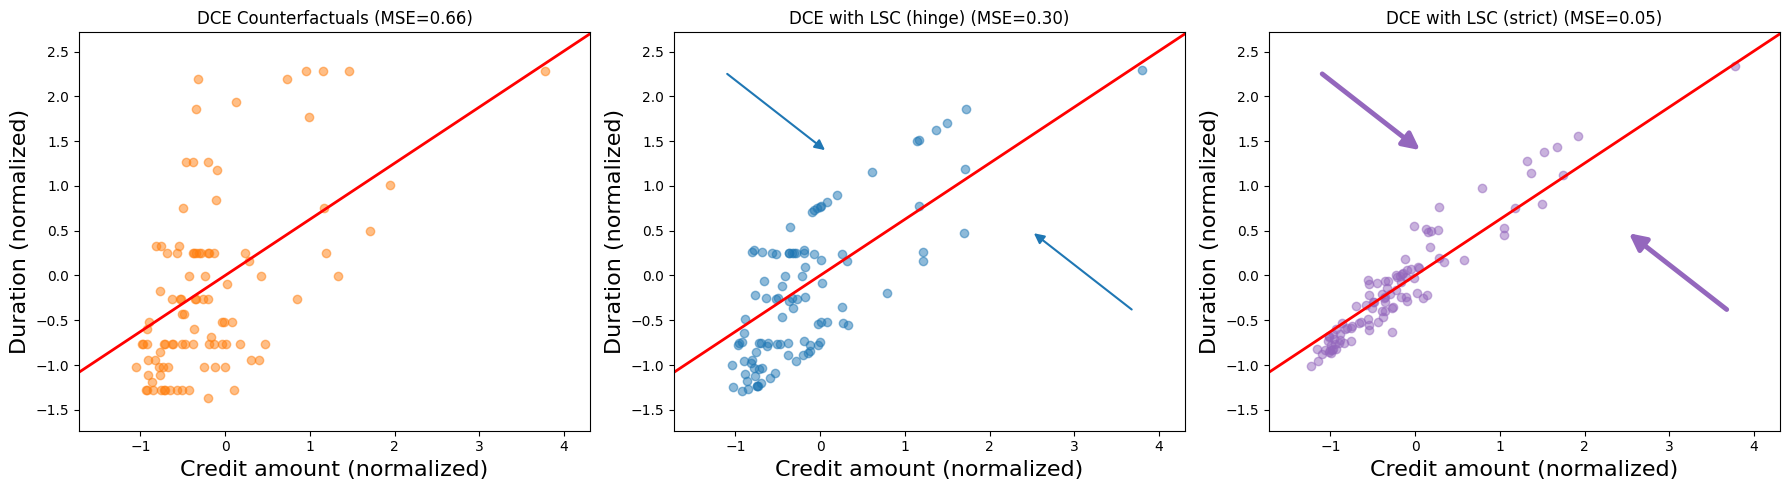

In [48]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

save_dir = "germancredit"

# ================== Read Excel files ==================
counterfactual_excel = pd.read_excel(
    os.path.join(save_dir, "counterfactual.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

lsc_hinge_excel = pd.read_excel(
    os.path.join(save_dir, "lsc_hinge_constraint.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

lsc_strict_excel = pd.read_excel(
    os.path.join(save_dir, "lsc_strict_constraint.xlsx"),
    sheet_name="counterfactual",
    index_col=0
)

# ================== Extract and normalize variables ==================
# Because lin_reg was fitted in normalized space, normalize Credit amount and Duration first.

X_s_credit = (
    (counterfactual_excel["Credit amount"].values - mean["Credit amount"])
    / std["Credit amount"]
).reshape(-1, 1)

y_s_true_duration = (
    (counterfactual_excel["Duration"].values - mean["Duration"])
    / std["Duration"]
)

X_s_credit_lsc_hinge = (
    (lsc_hinge_excel["Credit amount"].values - mean["Credit amount"])
    / std["Credit amount"]
).reshape(-1, 1)

y_s_true_duration_lsc_hinge = (
    (lsc_hinge_excel["Duration"].values - mean["Duration"])
    / std["Duration"]
)

X_s_credit_lsc_strict = (
    (lsc_strict_excel["Credit amount"].values - mean["Credit amount"])
    / std["Credit amount"]
).reshape(-1, 1)

y_s_true_duration_lsc_strict = (
    (lsc_strict_excel["Duration"].values - mean["Duration"])
    / std["Duration"]
)

# ================== Recalculate MSE in normalized space ==================
y_s_pred_duration = lin_reg.predict(X_s_credit)
y_s_pred_duration_lsc_hinge = lin_reg.predict(X_s_credit_lsc_hinge)
y_s_pred_duration_lsc_strict = lin_reg.predict(X_s_credit_lsc_strict)

mse_s = mean_squared_error(y_s_true_duration, y_s_pred_duration)
mse_s_lsc_hinge = mean_squared_error(y_s_true_duration_lsc_hinge, y_s_pred_duration_lsc_hinge)
mse_s_lsc_strict = mean_squared_error(y_s_true_duration_lsc_strict, y_s_pred_duration_lsc_strict)

# ================== Combine three plots for comparison ==================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  

# Unify the range of horizontal and vertical axes for all subplots
x_min = min(X_s_credit.min(), X_s_credit_lsc_hinge.min(), X_s_credit_lsc_strict.min())
x_max = max(X_s_credit.max(), X_s_credit_lsc_hinge.max(), X_s_credit_lsc_strict.max())
y_min = min(y_s_true_duration.min(), y_s_true_duration_lsc_hinge.min(), y_s_true_duration_lsc_strict.min())
y_max = max(y_s_true_duration.max(), y_s_true_duration_lsc_hinge.max(), y_s_true_duration_lsc_strict.max())

x_buffer = 0.1 * (x_max - x_min)
y_buffer = 0.1 * (y_max - y_min)
x_min, x_max = x_min - x_buffer, x_max + x_buffer
y_min, y_max = y_min - y_buffer, y_max + y_buffer

# Regression line for full range
x_line = np.linspace(x_min, x_max, 100).reshape(-1, 1)
y_line = lin_reg.predict(x_line)

# ========== Subplot 1: DCE without constraints ==========
axes[0].scatter(X_s_credit, y_s_true_duration, color="tab:orange", alpha=0.5)
axes[0].plot(x_line, y_line, color="red", linewidth=2) 
axes[0].set_xlabel("Credit amount (normalized)",fontsize=16)
axes[0].set_ylabel("Duration (normalized)",fontsize=16)
axes[0].set_title(f"DCE Counterfactuals (MSE={mse_s:.2f})")
axes[0].set_xlim(x_min, x_max)
axes[0].set_ylim(y_min, y_max)

# ========== Subplot 2: DCE + LSC (hinge) ==========
axes[1].scatter(X_s_credit_lsc_hinge, y_s_true_duration_lsc_hinge, color="tab:blue", alpha=0.5)
axes[1].plot(x_line, y_line, color="red", linewidth=2)  
axes[1].set_xlabel("Credit amount (normalized)",fontsize=16)
axes[1].set_ylabel("Duration (normalized)",fontsize=16)
axes[1].set_title(f"DCE with LSC (hinge) (MSE={mse_s_lsc_hinge:.2f})")
axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)

axes[1].annotate(
    '',
    xy=(0.7, 0.5),
    xytext=(0.9, 0.3),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        color="tab:blue",
        lw=1.5,
        mutation_scale=15
    )
)

axes[1].annotate(
    '',
    xy=(0.3, 0.7),
    xytext=(0.1, 0.9),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        color="tab:blue",
        lw=1.5,
        mutation_scale=15
    )
)

# ========== Subplot 3: DCE + LSC (strict) ==========
axes[2].scatter(X_s_credit_lsc_strict, y_s_true_duration_lsc_strict, color="tab:purple", alpha=0.5)  
axes[2].plot(x_line, y_line, color="red", linewidth=2)  
axes[2].set_xlabel("Credit amount (normalized)",fontsize=16)
axes[2].set_ylabel("Duration (normalized)",fontsize=16)
axes[2].set_title(f"DCE with LSC (strict) (MSE={mse_s_lsc_strict:.2f})")
axes[2].set_xlim(x_min, x_max)
axes[2].set_ylim(y_min, y_max)

axes[2].annotate(
    '',
    xy=(0.7, 0.5),
    xytext=(0.9, 0.3),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        color="tab:purple",
        lw=3.5,
        mutation_scale=25
    )
)

axes[2].annotate(
    '',
    xy=(0.3, 0.7),
    xytext=(0.1, 0.9),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        color="tab:purple",
        lw=3.5,
        mutation_scale=25
    )
)

plt.tight_layout()  
plt.show()

# **FSD**

FSDConstraint —— its role is to, under causal logic, infer from the improvement of y that x must move in a single direction as a whole (e.g., an increase in the proportion of Good → an overall left shift in Duration), ensuring that the counterfactual distribution is superior to the factual distribution at every probability point, and that there are no reverse situations that violate business logic.

Without FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied: False
Without FSD constraint: Number of violation points: 54
Without FSD constraint: Interval satisfaction ratio: 0.7148302


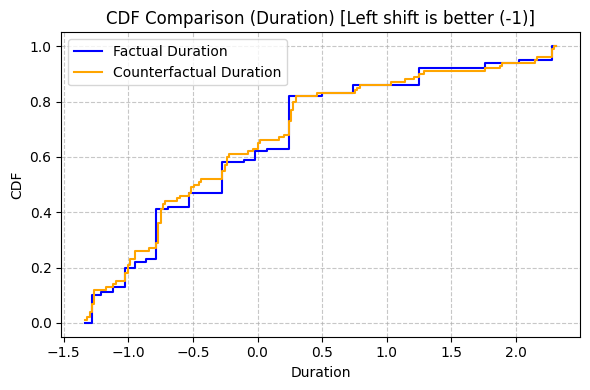

In [79]:
from explainers.constraints.FSDConstraint import FSDConstraintTorch

# ================== Duration distribution comparison (without FSD constraint) ==================
idx_duration = explain_columns.index("Duration")

fact_duration = X_t[:, idx_duration].cpu().numpy()
cf_duration   = X_s[:, idx_duration].cpu().numpy()

# Use the new version of the interface uniformly
result_cf = FSDConstraintTorch.check_FSD(
    fact_duration, cf_duration,
    direction=-1   #  Smaller Duration is better
)

print("Without FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied:", result_cf["holds"])
print("Without FSD constraint: Number of violation points:", len(result_cf["violations"]))
# print("Without FSD constraint: Point satisfaction ratio:", result_cf["point_ratio"])
print("Without FSD constraint: Interval satisfaction ratio:", result_cf["interval_ratio"])

# ================== Plot CDF comparison ==================
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=["#000000", "#2171b5"]   
)

FSDConstraintTorch.plot_cdf(
    fact=fact_duration,
    cf=cf_duration,
    feature_name="Duration",
    direction=-1
)


Whether in terms of the point satisfaction ratio or the interval satisfaction ratio, the counterfactual distribution with the FSD constraint added is more consistent with the expected left-shift trend overall.

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0295, term1=0.0304, term2=0.0295, penalty=2.481905460357666
INFO:root:U_1-Qu_upper=0.42327837573722094, U_2-Qv_upper=0.21490395035672316
INFO:root:eta=0.7440747015499972, l=0.278, r=1
INFO:root:Iter 2: Q=6.4063, term1=0.0017, term2=0.0041, penalty=6.40279483795166
INFO:root:U_1-Qu_upper=0.4875392015496302, U_2-Qv_upper=0.22095214156048876
INFO:root:eta=0.7748350099714938, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=6.7206, term1=0.0011, term2=0.0032, penalty=6.717920780181885
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23081137496808457
INFO:root:eta=0.7833729365562723, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=6.6014, term1=0.0008, term2=0.0029, penalty=6.59899377822876
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23758744801260573
INFO:root:eta=0.7901087261186581, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=6.6128, ter

With FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied: False
With FSD constraint: Number of violation points: 17
With FSD constraint: Interval satisfaction ratio: 0.9627475028016074
Mean Duration of factual distribution: -0.14186245699864822
Mean Duration of counterfactual with FSD constraint: -0.3944863


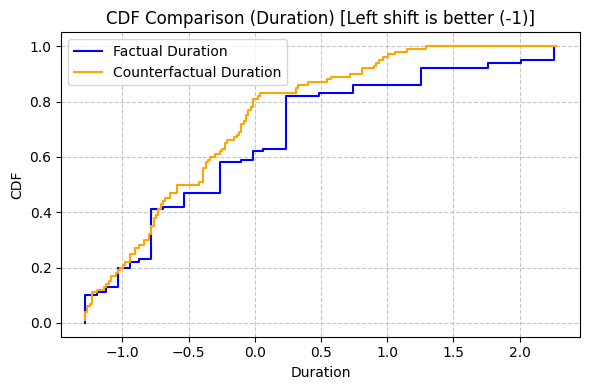

In [161]:
import numpy as np
import torch
from explainers.dce_v2 import DCEWithConstraints
from explainers.manager import ConstraintManager
from explainers.constraints.FSDConstraint import FSDConstraintTorch

# ================== 1. Define FSD constraint (Left shift of Duration is better) ==================
configs = [
    {
        "type": "fsd",
        "lambda": 1,   # 
        "dir_map": {"Duration": -1},   # Duration must shift left
        "M": 100,        
        "sample_mode": "quantile"
    }
]

feature_names = list(df_explain.columns)
constraint_manager = ConstraintManager(configs=configs, feature_names=feature_names)

# ================== 2. Initialize DCE with constraints ==================
set_seed(42)
explainer_fsd = DCEWithConstraints(
    model=model, 
    df_X=df_explain, 
    explain_columns=explain_columns,
    y_target=y_target, 
    lr=1e-1, 
    n_proj=N,
    delta=delta,
    constraint_manager=constraint_manager
)

# ================== 3. Optimize to generate counterfactuals ==================
set_seed(42)
explainer_fsd.optimize(U_1=0.5, U_2=0.3, l=0.2, r=1, max_iter=50, tau=1e3)

X_s_fsd = explainer_fsd.best_X[:, explainer_fsd.explain_indices].clone().detach()

# ================== 4. Check FSD conditions ==================
idx_duration = explain_columns.index("Duration")

fact_duration = df_explain.iloc[:, idx_duration].values
cf_duration_fsd = X_s_fsd[:, idx_duration].cpu().numpy()

result_fsd = FSDConstraintTorch.check_FSD(
    fact_duration, cf_duration_fsd,
    direction=-1   # Left shift of Duration is better
)

print("With FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied:", result_fsd["holds"])
print("With FSD constraint: Number of violation points:", len(result_fsd["violations"]))
# print("With FSD constraint: Point satisfaction ratio:", result_fsd["point_ratio"])
print("With FSD constraint: Interval satisfaction ratio:", result_fsd["interval_ratio"])
print("Mean Duration of factual distribution:", np.mean(fact_duration))
print("Mean Duration of counterfactual with FSD constraint:", np.mean(cf_duration_fsd))

# # ================== 5. Plot CDF comparison ==================
# FSDConstraintTorch.plot_cdf(
#     fact=fact_duration,
#     cf=cf_duration_fsd,
#     feature_name="Duration",
#     direction=-1
# )

In [166]:
import os
import pandas as pd
import torch

save_dir = "germancredit"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "fsd_constraint.xlsx")

# Convert FSD counterfactual X from normalized scale to original scale
cf_save_df = pd.DataFrame(
    explainer_fsd.best_X.detach().cpu().numpy(),
    columns=explain_columns
)

cf_save_df = cf_save_df * std[explain_columns] + mean[explain_columns]

# Prediction of FSD counterfactual samples by the black-box model
y_cf_pred = model(
    torch.FloatTensor(explainer_fsd.best_X.detach().cpu().numpy())
)

# Last three columns: true y, predicted y of CF, target y
cf_save_df["y_true"] = y_true.values.reshape(-1)
cf_save_df["y_cf_pred"] = y_cf_pred.detach().cpu().numpy().reshape(-1)
cf_save_df["y_target"] = y_target.detach().cpu().numpy().reshape(-1)

with pd.ExcelWriter(save_path, engine="openpyxl") as writer:
    cf_save_df.to_excel(
        writer,
        sheet_name="counterfactual",
        index=True
    )

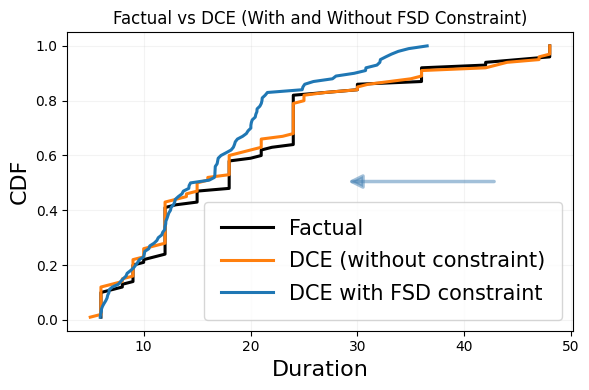

In [50]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================== 1. Read all data from saved Excel files ==================
fact_path = os.path.join("germancredit", "factual.xlsx")
dce_path = os.path.join("germancredit", "counterfactual.xlsx")
fsd_path = os.path.join("germancredit", "fsd_constraint.xlsx")

fact_df = pd.read_excel(fact_path, sheet_name="factual")
dce_df = pd.read_excel(dce_path, sheet_name="counterfactual")
cf_fsd_df = pd.read_excel(fsd_path, sheet_name="counterfactual")

# These Duration columns should already be in original scale
fact_duration = fact_df["Duration"].values
cf_duration = dce_df["Duration"].values
cf_duration_fsd = cf_fsd_df["Duration"].values

# ================== 2. Sort + CDF ==================
fact_sorted = np.sort(fact_duration)
fact_cdf = np.arange(1, len(fact_sorted) + 1) / len(fact_sorted)

cf_sorted = np.sort(cf_duration)
cf_cdf = np.arange(1, len(cf_sorted) + 1) / len(cf_sorted)

cf_fsd_sorted = np.sort(cf_duration_fsd)
cf_fsd_cdf = np.arange(1, len(cf_fsd_sorted) + 1) / len(cf_fsd_sorted)

# ================== 3. Plot ==================
plt.figure(figsize=(6, 4))

plt.plot(
    fact_sorted,
    fact_cdf,
    color="black",
    linewidth=2.2,
    label="Factual"
)

plt.plot(
    cf_sorted,
    cf_cdf,
    color="tab:orange",
    linewidth=2.2,
    label="DCE (without constraint)"
)

plt.plot(
    cf_fsd_sorted,
    cf_fsd_cdf,
    color="tab:blue",
    linewidth=2.2,
    label="DCE with FSD constraint"
)

# ================== 4. Arrow ==================
ax = plt.gca()
ax.annotate(
    '',
    xy=(0.55, 0.50),
    xytext=(0.85, 0.50),
    xycoords='axes fraction',
    textcoords='axes fraction',
    arrowprops=dict(
        arrowstyle='-|>',
        color="steelblue",
        alpha=0.5,
        lw=2.5,
        mutation_scale=20
    )
)

plt.xlabel("Duration",fontsize=16)
plt.ylabel("CDF",fontsize=16)
plt.title("Factual vs DCE (With and Without FSD Constraint)")
plt.grid(alpha=0.15)

plt.legend(
    frameon=True,
    loc="lower right",
    fontsize=15,
    markerscale=1.3,
    handlelength=2.5,
    borderpad=0.8,
    labelspacing=0.6
)

plt.tight_layout()
plt.show()

After adding the FSD constraint, the Duration distribution shifts left overall.


In [168]:
# ================== X  Wasserstein ==================
dist_X = np.sqrt(explainer.swd.distance(X_s, X_t, delta)[0].item())
dist_X_fsd = np.sqrt(explainer.swd.distance(X_s_fsd, X_t, delta)[0].item())

print(f"Wasserstein distance (X, Original DCE vs Factual): {dist_X:.4f}")
print(f"Wasserstein distance (X, FSD-DCE vs Factual): {dist_X_fsd:.4f}")

# ================== y  Wasserstein ==================
y_fsd = explainer_fsd.best_y.clone().detach()

dist_y = np.sqrt(explainer.wd.distance(cf_y, y_target, delta=delta)[0].item())
dist_y_fsd = np.sqrt(explainer.wd.distance(y_fsd, y_target, delta=delta)[0].item())

print(f"Wasserstein distance (y, Original DCE vs Target): {dist_y:.4f}")
print(f"Wasserstein distance (y, FSD-DCE vs Target): {dist_y_fsd:.4f}")


Wasserstein distance (X, Original DCE vs Factual): 0.0421
Wasserstein distance (X, FSD-DCE vs Factual): 0.0393
Wasserstein distance (y, Original DCE vs Target): 0.0682
Wasserstein distance (y, FSD-DCE vs Target): 0.0360


In [170]:
save_path = os.path.join(save_dir, "fsd_constraint.xlsx")

metrics_df = pd.DataFrame({
    "seed": [seed],
    "X_SWD_fsd_constraint": [float(dist_X_fsd)],
    "Y_WD_fsd_constraint": [float(dist_y_fsd)]
})

with pd.ExcelWriter(
    save_path,
    engine="openpyxl",
    mode="a",
    if_sheet_exists="replace"
) as writer:
    metrics_df.to_excel(
        writer,
        sheet_name="metrics",
        index=False
    )

Display the change in the number of violation points under different lambda values. Due to dataset limitations, even a very large lambda cannot guarantee that the number of violation points is zero.

In [53]:
# List of lambda values to test (5 points specified by you)
lambda_list = [0.5, 1, 5, 10, 50, 100]

# Result storage (save all exportable metrics)
all_results = {
    "lambda": [],
    "fsd_holds": [],          # Whether FSD is satisfied
    "violations_num": [],     # Number of violation points
    "point_ratio": [],        # Point satisfaction ratio
    "interval_ratio": [],     # Interval satisfaction ratio
    "fact_duration_mean": [], # Mean Duration of factual distribution
    "cf_duration_mean": [],   # Mean Duration of counterfactual distribution

    # Newly added: X-space and Y-space Wasserstein distances
    "x_space_swd": [],        # SWD between generated counterfactual X and factual X
    "y_space_wd": []          # WD between generated counterfactual y and target y
}

# ================== 2. Test each lambda in a loop ==================
idx_duration = explain_columns.index("Duration")  # Get Duration index in advance
fact_duration = df_explain.iloc[:, idx_duration].values  # Get factual Duration in advance
fact_mean = np.mean(fact_duration)  # Factual mean (fixed)

for lam in lambda_list:
    # 2.1 Define FSD constraint
    configs = [
        {
            "type": "fsd",
            "lambda": lam,
            "dir_map": {"Duration": -1},
            "M": 100,
            "sample_mode": "quantile"
        }
    ]
    feature_names = list(df_explain.columns)
    constraint_manager = ConstraintManager(configs=configs, feature_names=feature_names)
    
    # 2.2 Initialize DCE
    set_seed(42)
    explainer_fsd = DCEWithConstraints(
        model=model, 
        df_X=df_explain, 
        explain_columns=explain_columns,
        y_target=y_target, 
        lr=1e-1, 
        n_proj=N,
        delta=delta,
        constraint_manager=constraint_manager
    )
    
    # 2.3 Optimize to generate counterfactuals (same parameters as single lambda code)
    set_seed(42)
    explainer_fsd.optimize(U_1=0.5, U_2=0.3, l=0.2, r=1, max_iter=50, tau=1e3)
    
    # 2.4 Extract counterfactual Duration
    X_s_fsd = explainer_fsd.best_X[:, explainer_fsd.explain_indices].clone().detach()
    cf_duration_fsd = X_s_fsd[:, idx_duration].cpu().numpy()

    # 2.4.1 Compute X-space SWD: generated counterfactual X vs factual X
    X_t_fsd = torch.FloatTensor(df_explain[explain_columns].values).to(X_s_fsd.device)

    x_space_swd = np.sqrt(
        explainer_fsd.swd.distance(
            X_s_fsd,
            X_t_fsd,
            explainer_fsd.delta
        )[0].item()
    )

    # 2.4.2 Compute Y-space WD: generated counterfactual y vs target y
    y_fsd = explainer_fsd.best_y.clone().detach()

    y_space_wd = np.sqrt(
        explainer_fsd.wd.distance(
            y_fsd,
            y_target,
            delta=delta
        )[0].item()
    )
    
    # 2.5 Check FSD conditions
    result_fsd = FSDConstraintTorch.check_FSD(
        fact_duration, cf_duration_fsd,
        direction=-1
    )
    
    # 2.6 Populate results
    all_results["lambda"].append(lam)
    all_results["fsd_holds"].append(result_fsd["holds"])
    all_results["violations_num"].append(len(result_fsd["violations"]))
    all_results["point_ratio"].append(result_fsd["point_ratio"])
    all_results["interval_ratio"].append(result_fsd["interval_ratio"])
    all_results["fact_duration_mean"].append(fact_mean)
    all_results["cf_duration_mean"].append(np.mean(cf_duration_fsd))

    # Newly added: save X-space and Y-space distances under each lambda
    all_results["x_space_swd"].append(x_space_swd)
    all_results["y_space_wd"].append(y_space_wd)
    
    # 2.7 Print current results (same output format as single lambda code)
    print("With FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied:", result_fsd["holds"])
    print("With FSD constraint: Number of violation points:", len(result_fsd["violations"]))
    print("With FSD constraint: Point satisfaction ratio:", result_fsd["point_ratio"])
    print("With FSD constraint: Interval satisfaction ratio:", result_fsd["interval_ratio"])
    print("Mean Duration of factual distribution:", fact_mean)
    print("Mean Duration of counterfactual with FSD constraint:", np.mean(cf_duration_fsd))
    print("X-space SWD between factual and counterfactual:", x_space_swd)
    print("Y-space WD between target and counterfactual:", y_space_wd)

# ================== 3. Save all results to CSV (core) ==================
results_df = pd.DataFrame(all_results)
results_df.to_csv("germancredit/fsd_lambda_all_results.csv", index=False, encoding="utf-8")
print("\nAll results have been saved to: fsd_lambda_all_results.csv")

INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0295, term1=0.0304, term2=0.0295, penalty=1.2490816116333008
INFO:root:U_1-Qu_upper=0.42355949372923163, U_2-Qv_upper=0.21496169907034104
INFO:root:eta=0.7441417870921943, l=0.278, r=1
INFO:root:Iter 2: Q=3.2718, term1=0.0016, term2=0.0041, penalty=3.2683522701263428
INFO:root:U_1-Qu_upper=0.4883654333675237, U_2-Qv_upper=0.22030951633207202
INFO:root:eta=0.7755480550579892, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=3.3798, term1=0.0011, term2=0.0032, penalty=3.377141237258911
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.2308844306481056
INFO:root:eta=0.7833260302985138, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=3.4468, term1=0.0008, term2=0.0028, penalty=3.444377899169922
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.2374949925722432
INFO:root:eta=0.790164101188962, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=3.4675, te

With FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied: False
With FSD constraint: Number of violation points: 18
With FSD constraint: Point satisfaction ratio: 0.85
With FSD constraint: Interval satisfaction ratio: 0.9684133950668516
Mean Duration of factual distribution: -0.14186245699864822
Mean Duration of counterfactual with FSD constraint: -0.2951913
X-space SWD between factual and counterfactual: 0.029936311164492864
Y-space WD between target and counterfactual: 0.034059806466237526


INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0295, term1=0.0304, term2=0.0295, penalty=2.481905460357666
INFO:root:U_1-Qu_upper=0.42327837573722094, U_2-Qv_upper=0.21490395035672316
INFO:root:eta=0.7440747015499972, l=0.278, r=1
INFO:root:Iter 2: Q=6.4063, term1=0.0017, term2=0.0041, penalty=6.40279483795166
INFO:root:U_1-Qu_upper=0.4875392015496302, U_2-Qv_upper=0.22095214156048876
INFO:root:eta=0.7748350099714938, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=6.7206, term1=0.0011, term2=0.0032, penalty=6.717920780181885
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23081137496808457
INFO:root:eta=0.7833729365562723, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=6.6014, term1=0.0008, term2=0.0029, penalty=6.59899377822876
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=0.23758744801260573
INFO:root:eta=0.7901087261186581, l=0.38097525000000004, r=1
INFO:root:Iter 5: Q=6.6128, ter

With FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied: False
With FSD constraint: Number of violation points: 17
With FSD constraint: Point satisfaction ratio: 0.8583333333333333
With FSD constraint: Interval satisfaction ratio: 0.9627475028016074
Mean Duration of factual distribution: -0.14186245699864822
Mean Duration of counterfactual with FSD constraint: -0.3944863
X-space SWD between factual and counterfactual: 0.0392719687493024
Y-space WD between target and counterfactual: 0.03597827352810236


INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0295, term1=0.0306, term2=0.0295, penalty=11.774638175964355
INFO:root:U_1-Qu_upper=0.4210073553793159, U_2-Qv_upper=0.2143626797747496
INFO:root:eta=0.743589361136136, l=0.278, r=1
INFO:root:Iter 2: Q=29.2922, term1=0.0021, term2=0.0041, penalty=29.288599014282227
INFO:root:U_1-Qu_upper=0.47783306007630055, U_2-Qv_upper=0.22088305238827644
INFO:root:eta=0.7717562813002674, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=25.5435, term1=0.0015, term2=0.0035, penalty=25.540454864501953
INFO:root:U_1-Qu_upper=0.4934220867399889, U_2-Qv_upper=0.22788150830583415
INFO:root:eta=0.7833035525948793, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=24.9426, term1=0.0013, term2=0.0034, penalty=24.93963623046875
INFO:root:U_1-Qu_upper=0.49438876425022144, U_2-Qv_upper=0.23441858243371655
INFO:root:eta=0.7904133086724163, l=0.38097525000000004

...

With FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied: False
With FSD constraint: Number of violation points: 12
With FSD constraint: Point satisfaction ratio: 0.9
With FSD constraint: Interval satisfaction ratio: 0.9653628773435534
Mean Duration of factual distribution: -0.14186245699864822
Mean Duration of counterfactual with FSD constraint: -0.916533
X-space SWD between factual and counterfactual: 0.07820471928235673
Y-space WD between target and counterfactual: 0.037409355773698576


INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0324, term1=0.0370, term2=0.0324, penalty=63.02171325683594
INFO:root:U_1-Qu_upper=0.38015854464235743, U_2-Qv_upper=0.2065053611333757
INFO:root:eta=0.7324804322948048, l=0.278, r=1
INFO:root:Iter 2: Q=46.3936, term1=0.0280, term2=0.0213, penalty=46.37052917480469
INFO:root:U_1-Qu_upper=0.32266075648743153, U_2-Qv_upper=0.19723930509063847
INFO:root:eta=0.7260881680929429, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=28.4870, term1=0.0138, term2=0.0140, penalty=28.47307014465332
INFO:root:U_1-Qu_upper=0.34917370604635456, U_2-Qv_upper=0.2081851954545076
INFO:root:eta=0.7438020184521519, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=20.9756, term1=0.0114, term2=0.0070, penalty=20.967491149902344
INFO:root:U_1-Qu_upper=0.36304041730783615, U_2-Qv_upper=0.22385325227296626
INFO:root:eta=0.7514645224380907, l=0.38097525000000004

With FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied: False
With FSD constraint: Number of violation points: 9
With FSD constraint: Point satisfaction ratio: 0.925
With FSD constraint: Interval satisfaction ratio: 0.9971763345169499
Mean Duration of factual distribution: -0.14186245699864822
Mean Duration of counterfactual with FSD constraint: -1.1676179
X-space SWD between factual and counterfactual: 0.0717441131585098
Y-space WD between target and counterfactual: 0.038464816595211074


INFO:root:Optimization started
INFO:root:U_1-Qu_upper=0.5, U_2-Qv_upper=-0.004505061586421277
INFO:root:eta=1, l=0.24000000000000002, r=1
INFO:root:Iter 1: Q=0.0336, term1=0.0536, term2=0.0336, penalty=62.265750885009766
INFO:root:U_1-Qu_upper=0.3226433000735043, U_2-Qv_upper=0.19251754583209624
INFO:root:eta=0.7159851413490304, l=0.278, r=1
INFO:root:Iter 2: Q=19.6393, term1=0.0593, term2=0.0272, penalty=19.602977752685547
INFO:root:U_1-Qu_upper=0.22665661173126633, U_2-Qv_upper=0.18783792319529014
INFO:root:eta=0.6728087607451095, l=0.31410000000000005, r=1
INFO:root:Iter 3: Q=17.3652, term1=0.0173, term2=0.0074, penalty=17.35451889038086
INFO:root:U_1-Qu_upper=0.32598757009641965, U_2-Qv_upper=0.19550035004212402
INFO:root:eta=0.7428632861557596, l=0.34839500000000007, r=1
INFO:root:Iter 4: Q=9.3541, term1=0.0132, term2=0.0050, penalty=9.346966743469238
INFO:root:U_1-Qu_upper=0.3432108183721214, U_2-Qv_upper=0.1992633474513088
INFO:root:eta=0.7606503651304347, l=0.38097525000000004,

With FSD constraint: Whether First-Order Stochastic Dominance (FSD) is satisfied: False
With FSD constraint: Number of violation points: 9
With FSD constraint: Point satisfaction ratio: 0.925
With FSD constraint: Interval satisfaction ratio: 0.9989244631684581
Mean Duration of factual distribution: -0.14186245699864822
Mean Duration of counterfactual with FSD constraint: -1.2150364
X-space SWD between factual and counterfactual: 0.06325431209168518
Y-space WD between target and counterfactual: 0.03788066221787239

All results have been saved to: fsd_lambda_all_results.csv


INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
INFO:matplotlib.category:Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should

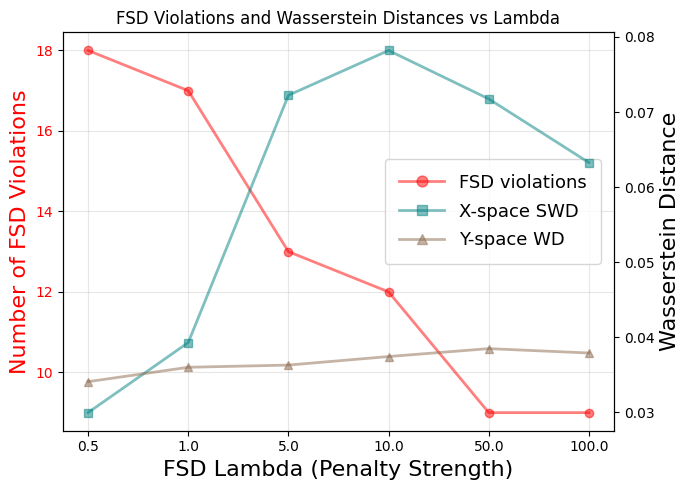

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.read_csv("germancredit/fsd_lambda_all_results.csv")

# Key: Convert lambda to string (force categorical axis)
results_df["lambda"] = results_df["lambda"].astype(str)

fig, ax1 = plt.subplots(figsize=(7, 5))

# ================== Left y-axis: FSD violations ==================
line1 = ax1.plot(
    results_df["lambda"],
    results_df["violations_num"],
    marker='o',
    alpha=0.5, 
    color='red',
    linewidth=2,
    markersize=6,
    label="FSD violations"
)

ax1.set_xlabel("FSD Lambda (Penalty Strength)",fontsize=16)
ax1.set_ylabel("Number of FSD Violations", color='red',fontsize=16)
ax1.tick_params(axis='y', labelcolor='red')
ax1.grid(alpha=0.3)

# ================== Right y-axis: X-space SWD and Y-space WD ==================
ax2 = ax1.twinx()

line2 = ax2.plot(
    results_df["lambda"],
    results_df["x_space_swd"],
    marker='s',
    color='teal',
    alpha=0.5, 
    linewidth=2,
    markersize=6,
    label="X-space SWD"
)

line3 = ax2.plot(
    results_df["lambda"],
    results_df["y_space_wd"],
    marker='^',
    color="#8C6A4F",
    alpha=0.5, 
    linewidth=2,
    markersize=6,
    label="Y-space WD"
)

ax2.set_ylabel("Wasserstein Distance", color='black',fontsize=16)
ax2.tick_params(axis='y', labelcolor='black')

# ================== Legend ==================
lines = line1 + line2 + line3
labels = [line.get_label() for line in lines]

ax1.legend(
    lines, labels,
    loc="center",
    bbox_to_anchor=(0.78, 0.55),
    ncol=1,
    fontsize=13,
    markerscale=1.3,
    handlelength=2.5,
    borderpad=0.8,
    labelspacing=0.6
)

plt.title("FSD Violations and Wasserstein Distances vs Lambda")
plt.tight_layout()

# plt.savefig("fsd_lambda_dual_axis.png", dpi=300, bbox_inches="tight")
plt.show()